# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Установка или обновление всех требуемых библиотек
# !pip install --upgrade pandas phik matplotlib seaborn jinja2 sqlalchemy


In [2]:
from sqlalchemy import create_engine 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik

In [3]:
# Настройки для подключения к БД
db_config = {
    'user': os.getenv("USER"),
    'pwd': os.getenv("PASSWORD"),
    'host': os.getenv("HOST"),
    'port': os.getenv("PORT"),
    'db': os.getenv("DB")
}

# Строка с настройками для содеинения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# Создание соединения с БД
engine = create_engine(connection_string)

In [4]:
# Выгрузка данных из запроса в датафрейм
query = """
SELECT
  user_id,
  device_type_canonical,
  order_id,
  created_dt_msk AS order_dt,
  created_ts_msk AS order_ts,
  currency_code,
  revenue,
  tickets_count,
    created_dt_msk::date - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk)::date AS days_since_prev,
  event_id,
  event_name_code AS event_name,
  event_type_main,
  service_name,
  region_name,
  city_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e USING(event_id)
LEFT JOIN afisha.city AS c USING(city_id)
LEFT JOIN afisha.regions AS r USING(region_id) 
WHERE p.device_type_canonical IN ('desktop', 'mobile') AND event_type_main <> 'фильм'
ORDER BY user_id ASC
"""

df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [5]:
# Первые пять строк из датафрейма
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [6]:
# Информация о столбцах датафрейма
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [7]:
# Метрики для числовых столбцов
df.describe()

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611,290611,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,2024-09-01 22:36:38.741272576,2024-09-02 13:31:19.397730560,625.584360,2.754311,3.222381,438019.834992
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,2024-07-30 00:00:00,2024-07-30 11:53:37.500000,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,2024-09-12 00:00:00,2024-09-12 14:02:10,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,2024-10-09 00:00:00,2024-10-09 15:57:55.500000,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,81174.540000,57.000000,148.000000,592325.000000
std,2.497551e+06,NaN,NaN,1227.693064,1.170620,11.350509,147423.078841


In [8]:
# Функция для вывода информации о пропусках в датафрейме
def show_missing_stats(df):
    df = pd.DataFrame({
        "Кол-во пропусков": df.isna().sum(),
        "Доля пропусков": df.isna().mean()
    })
    return df.style.format({"Доля пропусков": "{:.3f}"}).background_gradient(cmap="Reds")

In [9]:
# Пропуски с толбцах датафрейма
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
user_id,0,0.000
device_type_canonical,0,0.000
order_id,0,0.000
order_dt,0,0.000
order_ts,0,0.000
currency_code,0,0.000
revenue,0,0.000
tickets_count,0,0.000
days_since_prev,21933,0.075
event_id,0,0.000


Было успешно выгружено из базы данных 290611 строк с 15 столбцами. Полученный датафрейм занимает 33.3 Мб.
Во время предобработки данных необходимо будет **провести оптимизацию типов данных для числовых столбцов** (`order_id`, `revenue`, `tickets_count`, `days_since_prev` и `event_id`), а также для столбцов содержащих информацию о датах и времени (`order_dt` и `order_ts`), так как в текущий тип содержит наносекунды.

В столбце `revenue` **есть отрицательные значения**, которые скорее всего являются возвратами заказов, а также наблюдаются сильные выбросы.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [10]:
# Создание копии датафрейма для дальнейшего сравнения в предобработанной версией
df_copy = df.copy()

In [11]:
# Загрузка датасета, содержащего курс тенге к рублю
df_currency = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

In [12]:
# Информация о столбцах и первые пять строк
print(df_currency.info(), df_currency.head(), sep="\n\n\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB
None


         data  nominal     curs  cdx
0  2024-01-10      100  19.9391  kzt
1  2024-01-11      100  19.7255  kzt
2  2024-01-12      100  19.5839  kzt
3  2024-01-13      100  19.4501  kzt
4  2024-01-14      100  19.4501  kzt


В полученных данных не наблюдаются пропуски и значения в столбцах соответствуют их названиям, но столбец, содержащий дату, имеет тип object. Следует привести тип данных в данном столбце к типу datetime

In [13]:
# Приводим к типу datetime
df_currency["data"] = pd.to_datetime(df_currency["data"]).astype('datetime64[s]')

In [14]:
# Объединяем датафреймы
df = df.merge(df_currency[["data", "curs"]], left_on="order_dt", right_on="data", how="left")

In [15]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,curs
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,18.6972
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,18.3419
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,19.6475
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,2024-07-13,18.5010
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,2024-10-04,19.6648


In [16]:
# Новый столбец, содержащий выручку в рублях
df["revenue_rub"] = df.apply(
    lambda row: row["revenue"] * row["curs"] if row["currency_code"] == "kzt" else row["revenue"], 
    axis = 1
)
df = df.drop(["curs", "data"], axis=1)

In [17]:
# Проверяем, что не появилось пропусков в столбце revenue_rub
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [18]:
# Пропуски в датафрейме
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
user_id,0,0.000
device_type_canonical,0,0.000
order_id,0,0.000
order_dt,0,0.000
order_ts,0,0.000
currency_code,0,0.000
revenue,0,0.000
tickets_count,0,0.000
days_since_prev,21933,0.075
event_id,0,0.000


Пропуски, содержаться только в столбце `days_since_prev`, значит выгрузка была успешной. Преобразуем сначала типы данных в числовых столбцах, а затем в столцах, содержащих дату и время.

**Оптимизация типов данных для числовых столбцов**

In [19]:
# Функция для проверки можно ли изменить тип столбца на integer
def is_int_series(x: pd.Series) -> bool:
    return x.dropna().apply(lambda x: x.is_integer()).all()

In [20]:
# Столбцы датафрейма, имеющие тип данных int
columns_int = df.select_dtypes(include=['int']).columns.tolist()
# Столбцы датафрейма, имеющие тип данных float
columns_float = df.select_dtypes(include=['float']).columns.tolist()

print(f"Целочисленные столбцы: {', '.join(columns_int)}")
print(f"Вещественные столбцы: {', '.join(columns_float)}")

Целочисленные столбцы: order_id, tickets_count, event_id
Вещественные столбцы: revenue, days_since_prev, revenue_rub


In [21]:
# Столбцы датафрейма, которые можно преобразовать в целочисленный тип
cols_to_int = {col:"Int64" for col in columns_float if is_int_series(df[col])}
print(cols_to_int.keys())

dict_keys(['days_since_prev'])


In [22]:
# Преобразование найденных вещественных столбцов в целочисленный тип данных 
df = df.astype(cols_to_int)

In [23]:
# Оптимизируем столбцы с числовыми типами данных
for col in columns_int + list(cols_to_int.keys()):
    df[col] = pd.to_numeric(df[col], downcast="integer")
    
for col in [i for i in columns_float if i not in list(cols_to_int.keys())]:
    df[col] = pd.to_numeric(df[col], downcast="float")

**Оптимизация типов данных для столбцов, содержащих дату и время**

In [24]:
# Столбцы датафрейма, имеющие тип данных datetime
columns_datetime = df.select_dtypes(include=['datetime']).columns.tolist()

# Преобразование к типу данных datetime[s]
df[columns_datetime] = df[columns_datetime].astype("datetime64[s]")

**Оптимизация для столбца `currency_code`**

Так как данный столбец содержит всего два значения ("rub" и "kzt"), его можно преобразовать в два столбца с типом данных boolean, что позволит уменьшить количество потребляемой памяти. 

In [25]:
# Создаём два столбца для валюты
df = pd.get_dummies(df, columns=["currency_code"])

Проверим типы данных после оптимизации

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                290611 non-null  object       
 1   device_type_canonical  290611 non-null  object       
 2   order_id               290611 non-null  int32        
 3   order_dt               290611 non-null  datetime64[s]
 4   order_ts               290611 non-null  datetime64[s]
 5   revenue                290611 non-null  float64      
 6   tickets_count          290611 non-null  int8         
 7   days_since_prev        268678 non-null  Int16        
 8   event_id               290611 non-null  int32        
 9   event_name             290611 non-null  object       
 10  event_type_main        290611 non-null  object       
 11  service_name           290611 non-null  object       
 12  region_name            290611 non-null  object       
 13 

**Изучение значений в столбцах, содержащих номинальные значения**

Выделим категориальные столбцы, которые могут содержать заглушки для пропусков

In [27]:
columns_cat = [
    "device_type_canonical",
    "event_type_main",
    "service_name",
    "region_name",
    "city_name"
]

In [28]:
for col in columns_cat:
    print(f"""Уникальные значения в столбце "{col}": \n{sorted(df[col].unique())} """)

Уникальные значения в столбце "device_type_canonical": 
['desktop', 'mobile'] 
Уникальные значения в столбце "event_type_main": 
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки'] 
Уникальные значения в столбце "service_name": 
['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная', 'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет', 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко'] 
Уникальные значения в столбце "region_name": 
['Белоярская область', 'Берестовский округ', 'Берёзовская область', 'Боровлянский край', 'Верховинская область', 'Верхозёрский край', 'Верхоречная область', 

В столбце `event_type_main` есть значение "другое". Проверим является ли оно заглушкой для пропусков - если таких значений будет значительная часть, то "другое" скорее всего является заглушкой.

In [29]:
# Доля для каждого значения столбца event_type_main
df["event_type_main"].value_counts() / df.shape[0]

event_type_main
концерты    0.396668
театр       0.231653
другое      0.226650
спорт       0.075396
стендап     0.046086
выставки    0.016703
ёлки        0.006844
Name: count, dtype: float64

Доля значения "другое" составляет 22%, поэтому будем считать это значение полноценной категорией.
Итого заглушек для пропусков найдено не было.

Проверим необходимость в нормализации данных в категориальных столбцах - если количество уникальных значений не совпадает с количеством уникальных значений в нормализованных данных, то нормализация необходима.

In [30]:
for col in columns_cat:
    nunique1 = df[col].nunique()
    nunique2 = (df[col].str.lower().str.strip()).nunique()
    print(
f"""
Столбец "{col}":
    количество уникальных: {nunique1}
    количество уникальных в нормализованном: {nunique2}
    нужна нормализация: {"Нет" if nunique1 == nunique2 else "Да"}
"""
    )


Столбец "device_type_canonical":
    количество уникальных: 2
    количество уникальных в нормализованном: 2
    нужна нормализация: Нет


Столбец "event_type_main":
    количество уникальных: 7
    количество уникальных в нормализованном: 7
    нужна нормализация: Нет


Столбец "service_name":
    количество уникальных: 36
    количество уникальных в нормализованном: 36
    нужна нормализация: Нет


Столбец "region_name":
    количество уникальных: 81
    количество уникальных в нормализованном: 81
    нужна нормализация: Нет


Столбец "city_name":
    количество уникальных: 352
    количество уникальных в нормализованном: 352
    нужна нормализация: Нет



Так как для всех столбцов количество уникальных значений в обоих случаях одинаково, нормализация не требуется.

**Изучение значений в числовых столбцах**

Для столбцов `revenue_rub` и `tickets_count` выведем их статистические показатели, гистограмму распределения и диаграмму размаха

In [31]:
import math

def distrib_of_column(
    series: pd.Series,
    description_text:str,
    title:str,
    xlabel:str,
    fixed_bins=None, 
    density=False, 
    need_boxplot=True
):
    
    # Выводим статистические показатели
    print(f"""{description_text}:\n{series.describe().rename({'50%': 'median'})}""")
    
    # Отрисовываем гистограму, количество бинов вычисляем по формуле, обычно используемой в мат. статистике
    series.plot(
        kind="hist",
        figsize=(8, 6),
        grid=True,
        title=title,
        xlabel=xlabel,
        ylabel="Частота",
        bins = fixed_bins if fixed_bins else math.ceil(len(series)**(1/3)),
        edgecolor="black",
        density=density
    )
    plt.show()
    
    if need_boxplot:
        # Отрисовываем диаграмму размаха
        series.plot(
            kind="box",
            figsize=(8, 6),
            grid=True,
            title=title,
            xlabel=xlabel,
            vert=False
        )
        plt.show()
    
    # Вычисляем количество выбросов
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lt_bound = Q1 - 1.5*IQR
    rt_bound = Q3 + 1.5*IQR
    
    out_lt = series[(series < lt_bound)]
    out_rt = series[(series > rt_bound)]
    
    cnt_out_lt = len(out_lt)
    cnt_out_rt = len(out_rt)
    
    cnt_out = len(out_lt) + len(out_rt)
    
    # Выводим инфомрацию о выбросах
    print(f"Количество выбросов: \n\tвсего: {cnt_out} ({round(cnt_out / len(series) * 100, 1)}%)")
    if cnt_out != 0:
        print(f"\tслева (до значения {round(lt_bound, 2)}): {cnt_out_lt} ({round(cnt_out_lt / len(series) * 100, 1)}%)")
        print(f"\tсправа (от значения {round(rt_bound, 2)}): {cnt_out_rt} ({round(cnt_out_rt / len(series) * 100, 1)}%)")

Статистические показатели для выручки в рублях:
count     290611.000000
mean        2250.137525
std        18160.775009
min          -90.760000
25%          116.990000
median       359.400000
75%          823.930000
max       525684.347808
Name: revenue_rub, dtype: float64


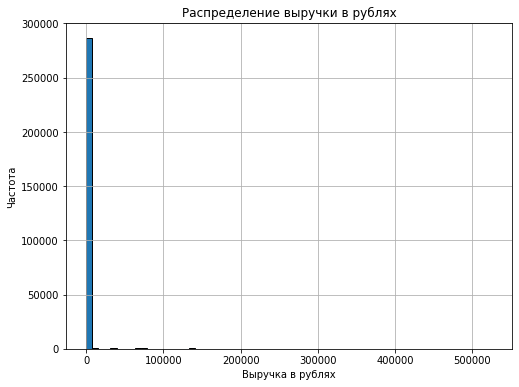

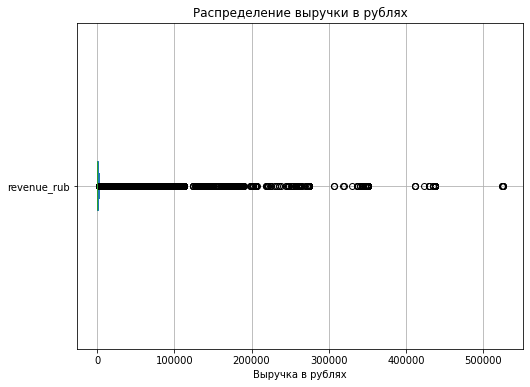

Количество выбросов: 
	всего: 13977 (4.8%)
	слева (до значения -943.42): 0 (0.0%)
	справа (от значения 1884.34): 13977 (4.8%)


In [32]:
distrib_of_column(
    df["revenue_rub"],
    "Статистические показатели для выручки в рублях",
    "Распределение выручки в рублях", 
    "Выручка в рублях"
)

Столбец `revenue_rub` имеет большое количество выбросов справа (4.8%), медианой является значение 359, а минимальным и максимальным значениями являются -90 и 525684 соответственно. В данном столбце нужно будет отфильтровать значения по 99 перцентилю.

Статистические показатели для количества купленных билетов:
count     290611.000000
mean           2.754311
std            1.170620
min            1.000000
25%            2.000000
median         3.000000
75%            4.000000
max           57.000000
Name: tickets_count, dtype: float64


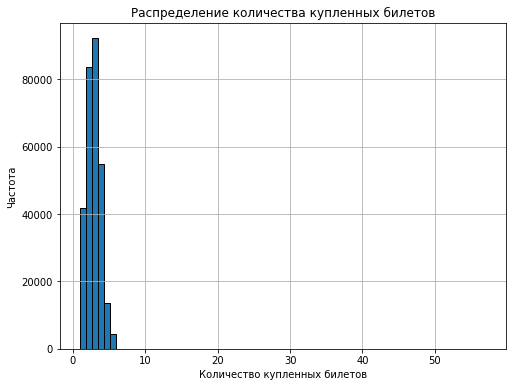

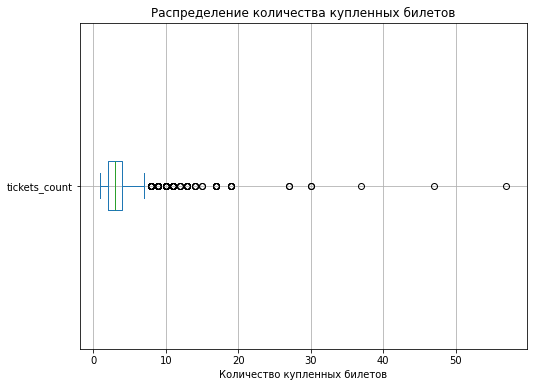

Количество выбросов: 
	всего: 126 (0.0%)
	слева (до значения -1.0): 0 (0.0%)
	справа (от значения 7.0): 126 (0.0%)


In [33]:
distrib_of_column(
    df["tickets_count"],
    "Статистические показатели для количества купленных билетов",
    "Распределение количества купленных билетов", 
    "Количество купленных билетов"
)

В столбце `tickets_count` также имеются выбросы справа (126 значений), при этом большая часть значений лежит в диапазоне от 1 до 4, а максимальным значением является 57.

Из оставшихся числовых столбцов рассмотрим только `days_since_prev`, так как столбцы `order_id` и `event_id` являются просто уникальными идентификаторами из других таблиц базы данных, а столбец `revenue` ент смысла анализировать, так как он содержит данные о цене срау в двух валютах.

Статистические показатели для количества дней между покупками:
count      268678.0
mean       3.222381
std       11.350509
min             0.0
25%             0.0
median          0.0
75%             1.0
max           148.0
Name: days_since_prev, dtype: Float64


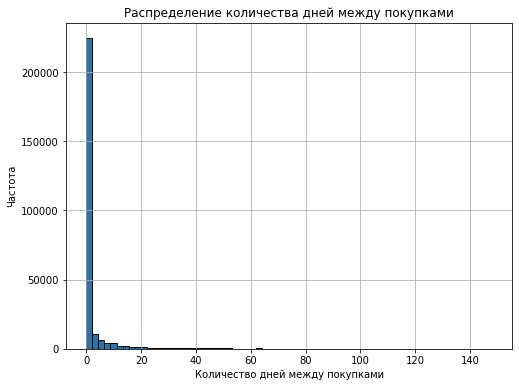

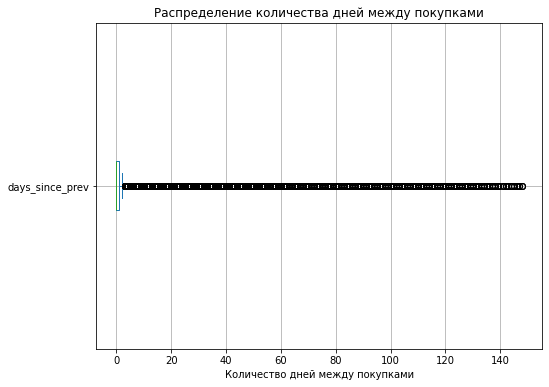

Количество выбросов: 
	всего: 44207 (15.2%)
	слева (до значения -1.5): 0 (0.0%)
	справа (от значения 2.5): 44207 (15.2%)


In [34]:
distrib_of_column(
    df["days_since_prev"],
    "Статистические показатели для количества дней между покупками",
    "Распределение количества дней между покупками", 
    "Количество дней между покупками"
)

В столбце `days_since_prev` большую часть значений составляют 0 и 1, а среднее количество дней между заказами равняется 3. В данном столбце также есть выбросы справа, и их количество существенно - 44207 (15.2%).

Теперь проведём фильтрацию в столбце `revenue_rub`.

In [35]:
# Оставляем в датафрейме только те строки, в которых значение выручки в рублях меньше 99 перцентиля
df = df[df["revenue_rub"] <= df["revenue_rub"].quantile(0.99)].copy()

# Сбрасываем индекс, для оптимизации по памяти
df = df.reset_index(drop=True)

In [36]:
a, b = len(df_copy), len(df)
print(
    f"""
Было строк в исходном датасете: {a}
Осталось строк в датасете после обработки: {b}
Удалено строк в датасете после обработки: {a-b}
Процент потерь: {round((a-b)/a*100, 2)}
"""
)


Было строк в исходном датасете: 290611
Осталось строк в датасете после обработки: 287705
Удалено строк в датасете после обработки: 2906
Процент потерь: 1.0



In [37]:
print("Информация о столбцах исходного датафрейма:")
df_copy.info()

Информация о столбцах исходного датафрейма:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  

In [38]:
print("Информация о столбцах предобработанного датафрейма")
df.info()

Информация о столбцах предобработанного датафрейма
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287705 entries, 0 to 287704
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                287705 non-null  object       
 1   device_type_canonical  287705 non-null  object       
 2   order_id               287705 non-null  int32        
 3   order_dt               287705 non-null  datetime64[s]
 4   order_ts               287705 non-null  datetime64[s]
 5   revenue                287705 non-null  float64      
 6   tickets_count          287705 non-null  int8         
 7   days_since_prev        266270 non-null  Int16        
 8   event_id               287705 non-null  int32        
 9   event_name             287705 non-null  object       
 10  event_type_main        287705 non-null  object       
 11  service_name           287705 non-null  object       
 12  region_

Во время предобработки была проведена проверка наличия пропусков в полученных данных, в результате которые выяснилось, что пропуски содержаться только в столбце `days_since_prev`. Данные пропуски можно считаь индикатором того, что данный заказ является первым для конкретного пользователя.

Далее были оптимизированны типы данных в датафрейме. Столбцы `order_id`, `tickets_count`, `days_since_prev` и `event_id` были преобразованы к типам данных **int32**, **int8**, **Int16** и **int32** соответственно. А столбец `currency_code` был преобразован в два булевых столбца `currency_code_rub` (является ли валюта оплаты рублём), `currency_code_rub` (является ли валюта оплаты тенге) со типами данных bool.

Также ходе преобработки данных был **создан новый столбец** `revenue_rub`, который **содержит выручку в рублях** (значения в тенге были преобразованы в рубли с помощью вспомогательного датасета, содержащего курсы валют).

Были проверены выбросы в числовых столбцах `revenue_rub`, `tickets_count` и `days_since_prev`. **Все три столбца имеют выбросы справа**, а наибольшее количество выбросов находилось в столбцах `revenue_rub` и `days_since_prev` - 13977 (4.8%) и 44207 (15.2%) соответственно. В столбце revenue_rub **была проведена фильтрация** по 99 перцентилю, в следствии чего из датафрейма **было удалено 2906 строк (1.0%)**.

После предобработки данных датафрейма его объём памяти удалось снизить с 33.3 Мб до 28.0 Мб.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [39]:
# Сортировка данных по id клиента и по времени совершения заказа
df_sorted = df.sort_values(["user_id", "order_ts"], ascending=[True, True]).reset_index(drop=True)
df_sorted.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub,currency_code_kzt,currency_code_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,1521.94,4,<NA>,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94,False,True
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,289.45,2,<NA>,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45,False,True
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,1258.57,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57,False,True
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,8.49,2,<NA>,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49,False,True
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,1390.41,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41,False,True


In [40]:
# Группируем данные по user_id и вычислияем требуемые столбцы
df_profile = df_sorted.groupby("user_id").agg(
    dt_first=("order_dt", "first"),
    dt_last=("order_dt", "last"),
    device_first=("device_type_canonical", "first"),
    region_first=("region_name", "first"),
    service_first=("service_name", "first"),
    genre_first=("event_type_main", "first"),
    count_orders=("order_id", "count"),
    avg_revenue=("revenue", "mean"),
    avg_tickets=("tickets_count", "mean"),
    avg_days_between=("days_since_prev", "mean")
)

In [41]:
# Создаём столбцы is_two и is_five
df_profile["is_two"] = df_profile["count_orders"] >= 2
df_profile["is_five"] = df_profile["count_orders"] >= 5

In [42]:
# Пересоздание индекса
df_profile = df_profile.reset_index()

# Первые пять строк полученного датафрейма
df_profile.head(5)

,user_id,dt_first,dt_last,device_first,region_first,service_first,genre_first,count_orders,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [43]:
# Вывод сводки по датафрейму.

# При расчёте средней выручки с одного заказа, 
# делим на количество записей в датафрейме, так 
# как при анализе данных с помощью SQL запросов 
# была проверена уникальность идентификаторов
print(
f"""
Общее число пользователей: {df_profile.shape[0]}
Средняя выручка с одного заказа: {round(df["revenue"].sum() / df.shape[0], 2)}
Доля пользователей, совершивших 2 и более заказа: {round(df_profile["is_two"].mean(), 2)}
Доля пользователей, совершивших 5 и более заказов: {round(df_profile["is_five"].mean(), 2)}
"""
)


Общее число пользователей: 21723
Средняя выручка с одного заказа: 548.91
Доля пользователей, совершивших 2 и более заказа: 0.62
Доля пользователей, совершивших 5 и более заказов: 0.29



**Анализ статистических показателей**

Статистические показатели для количества заказов пользователей:
count     21723.000000
mean         13.244257
std         122.327117
min           1.000000
25%           1.000000
median        2.000000
75%           5.000000
max       10204.000000
Name: count_orders, dtype: float64


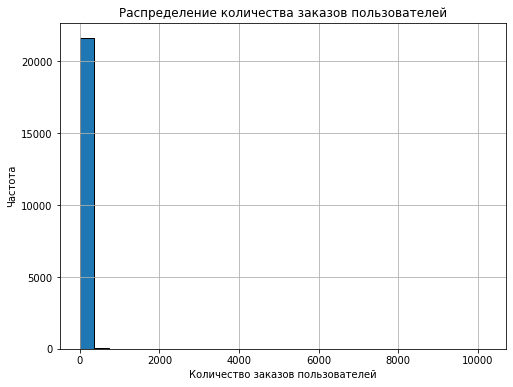

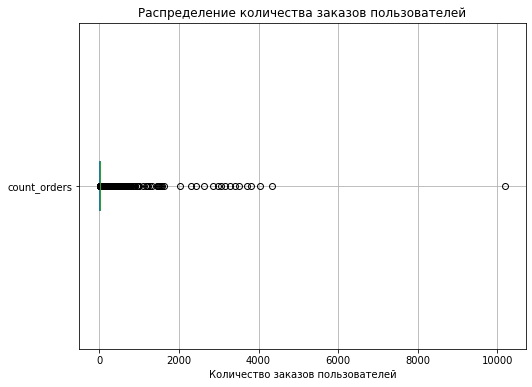

Количество выбросов: 
	всего: 2753 (12.7%)
	слева (до значения -5.0): 0 (0.0%)
	справа (от значения 11.0): 2753 (12.7%)


In [44]:
# Общее количество заказов
distrib_of_column(
    df_profile["count_orders"],
    "Статистические показатели для количества заказов пользователей",
    "Распределение количества заказов пользователей", 
    "Количество заказов пользователей"
)

Статистические показатели для среднего количества купленных билетов пользователями:
count     21723.000000
mean          2.753107
std           0.925773
min           1.000000
25%           2.000000
median        2.753846
75%           3.125000
max          12.000000
Name: avg_tickets, dtype: float64


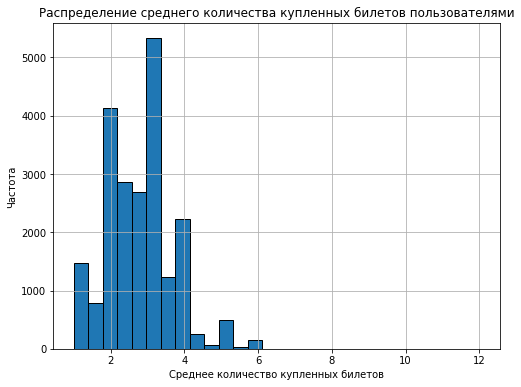

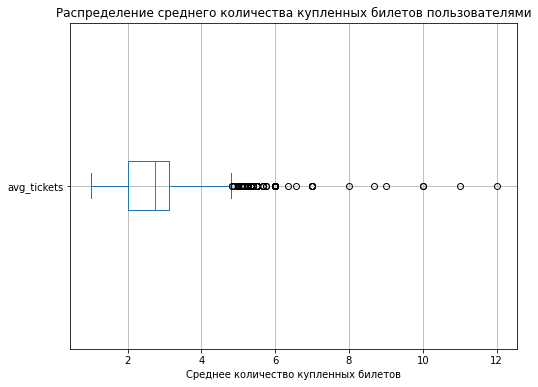

Количество выбросов: 
	всего: 691 (3.2%)
	слева (до значения 0.31): 0 (0.0%)
	справа (от значения 4.81): 691 (3.2%)


In [45]:
# Среднее число билетов в заказе
distrib_of_column(
    df_profile["avg_tickets"],
    "Статистические показатели для среднего количества купленных билетов пользователями",
    "Распределение среднего количества купленных билетов пользователями", 
    "Среднее количество купленных билетов"
)

Статистические показатели для среднего количества дней между заказами:
count       13465.0
mean       15.98547
std       22.431186
min             0.0
25%             1.0
median     8.153846
75%       20.666667
max           148.0
Name: avg_days_between, dtype: Float64


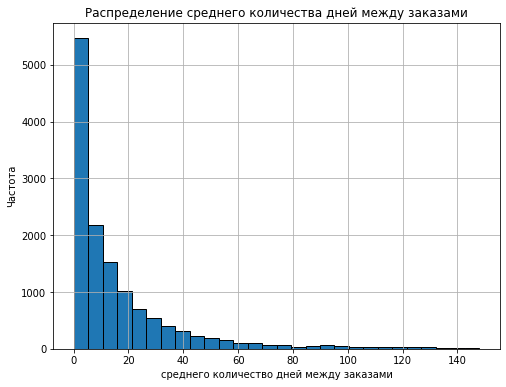

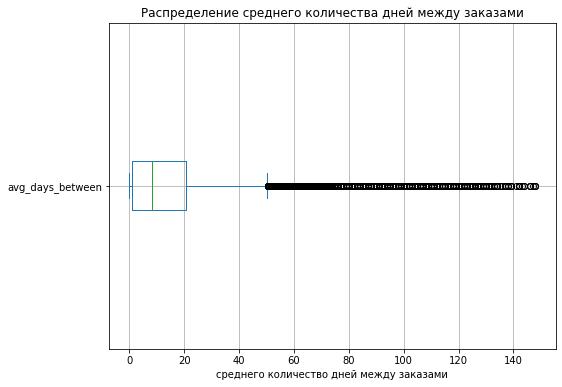

Количество выбросов: 
	всего: 995 (4.6%)
	слева (до значения -28.5): 0 (0.0%)
	справа (от значения 50.17): 995 (4.6%)


In [46]:
# Среднее количество дней между покупками
distrib_of_column(
    df_profile["avg_days_between"],
    "Статистические показатели для среднего количества дней между заказами",
    "Распределение среднего количества дней между заказами", 
    "среднего количество дней между заказами"
)

В результате создания профиля пользователя **была получена информация о 21723 пользователях**. Такое количество данных является достаточным для дальнейшего анализа. Средняя выручка с одного заказа составляет **549 рублей**, **62%** пользователей совершили 2 и более заказа, а **29%** сделали 5 заказов и более. Эти данные демонстрируют **хорошее удержание пользователей** на платформе, так как большинство (62%) возвращается хотя бы один раз, а значительная часть пользователей (29%) делает большое количество заказов.

В столбце, содержащем общее количество заказов пользователя, есть выбросы справа в количестве **2753 значений (12.7%)**. **Медиана составляет 2 заказа**, а **среднее - 13.24**, что объясняется сильными выбросами справа, а **максимальным значением в данных является 10204 заказа**. Можно предположить, что данные выбросы были получены в результате **массовых заказов другими компаниями**, занимающимися перепродажей билетов, или **технической ошибкой в работе сервиса**, так как даже 150 заказов билетов за 5 месяцев, охватываемых полученными данными, означает посещение пользователем в среднем одного мероприятия каждый день, что свойственно далеко не всем людям. Данные в этом столбце следует отфильтровать, потому что данные выбросы могут сильно повлиять на последующий анализ. Перцентиль для фильтрации будет определён позже.

В столбце, содержащем среднее число билетов в заказе, также есть выбросы справа, но в гораздо меньших количествах - **691 значение (3.2%)**. Среднее и медиана в данном столбце примерно равны **2.75**, что говорит о примерно симметричном распределении. Также максимальным значением в столбце является 12 заказов, что не является сильным выбросом. Данные в этом с толбце не стоит фильтровать, так как выбросов малое количество и все они не являются аномальными значениями (максимальное значение в 12 заказов возможно, когда человек покупает билеты сразу на большую компанию).

В столбце со средним временем между заказами обнаружены выбросы справа в количестве **995 (4.6%)**. Медианой и средним значением является **8.15** и **16.98** соответственно, а максимальное значение достигает **148 дней**. Значения в данном столбце имеют явное **показательное распределение**, которое как раз свойственно для последовательных совершений одного события (заказа билетов). Значения в данном столбце не будут отфильтрованы, так как данные имеют правильное для своего описания распределение и большое количесвто дней между заказами (148 дней) не является аномалией.

**Фильтрация в столбце `count_orders`**

In [47]:
# Копия датафрейма перед фильтрацией
df_profile_copy = df_profile.copy()

Проверим значения 99- и 95-ого перцентилей столбца с количество заказов пользователя.

In [48]:
print(
f"""99-ый перцентиль: {df_profile["count_orders"].quantile(0.99)}
95-ый перцентиль: {df_profile["count_orders"].quantile(0.95)}"""
     )

99-ый перцентиль: 151.77999999999884
95-ый перцентиль: 32.0


Значение 99-ого перцентиля всё ещё является аномалией, а 95-ый перцентиль описывает количество заказов для очень активного пользователя, поэтому следует применить фильтрацию по 95-му перцентилю.

In [49]:
# Фильтрация по 95 перцентилю
df_profile = df_profile[df_profile["count_orders"] <= df_profile["count_orders"].quantile(0.95)].copy()

# Сбрасываем индекс, для оптимизации по памяти
df_profile = df_profile.reset_index(drop=True)

In [50]:
# Статистические показатели для отфильтрованного столбца
df_profile["count_orders"].describe()

count    20661.000000
mean         4.095591
std          5.222347
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         32.000000
Name: count_orders, dtype: float64

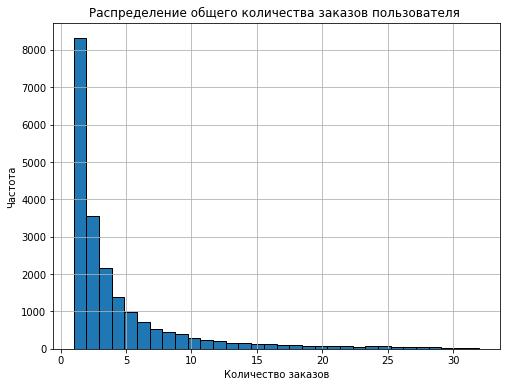

In [51]:
# Гистограмма для отфильтрованного столбца count_orders

df_profile["count_orders"].plot(
        kind="hist",
        figsize=(8, 6),
        grid=True,
        title=f"""Распределение общего количества заказов пользователя """,
        xlabel="Количество заказов",
        ylabel="Частота",
        bins = 32,
        edgecolor="black"
    )
plt.show()

В отфильтрованном столбце, содержащем количество заказов пользователя, медианой и средним значениями являются **2** и **4.09** соответственно, а максимальным значением - **32 заказа**. Также исходя из полученной гистограммы для значений столбца `count_orders`, можно сделать вывод, что его значения также как и в столбце `avg_days_between` имеют приблизительно логарифмическое распределение.

In [52]:
a, b = len(df_profile_copy), len(df_profile)
print(
    f"""
Было строк в исходном датасете: {a}
Осталось строк в датасете после обработки: {b}
Удалено строк в датасете после обработки: {a-b}
Процент потерь: {round((a-b)/a*100, 2)}
"""
)


Было строк в исходном датасете: 21723
Осталось строк в датасете после обработки: 20661
Удалено строк в датасете после обработки: 1062
Процент потерь: 4.89



В процессе обработки профилей пользователей **было удалено 1062 строки**, что составляет **4.89%** от всех данных в изначальном датафрейме, содержащем профиль пользователя.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [53]:
# Группировка пользователей по типу первого мероприятия
df_profile_genre_first = df_profile.groupby("genre_first")["user_id"].count()

# Группировка пользователей по типу первого устройства
df_profile_device_first = df_profile.groupby("device_first")["user_id"].count()

# Группировка пользователей по региону первого заказа
df_profile_region_first = df_profile.groupby("region_first")["user_id"].count()

# Группировка пользователей по оператору первого заказа
df_profile_service_first = df_profile.groupby("service_first")["user_id"].count()

In [54]:
# Функция для отрисовки столбчатой диаграммы
def barplot_of_series(
    series:pd.Series, 
    title, 
    xlabel, 
    ylabel, 
    vert:bool=True, 
    percent_format:str="0.01%", 
    figsize:tuple[float, float]=(10, 10)
):
    # Сумма значений серии
    total_count = series.sum()
    # Столбчатая диаграмма для категорий в столбце
    plot = series.sort_values().plot(
        kind="bar" if vert else "barh",
        grid=True,
        title=title,
        xlabel=xlabel if vert else ylabel,
        ylabel=ylabel if vert else xlabel,
        figsize=figsize,
        linewidth=2,
        edgecolor="black",
        rot=0,
    )
    
    # Разделитель между количеством и долей
    sep = '\n' if vert else ' '
    
    # Добавление подписей к столбцам
    plot.bar_label(
        plot.containers[0], 
        labels=[f"{i}{sep}({format(i / total_count, percent_format)})" for i in series.sort_values()],
        padding=5,
        fontweight='bold'
    )
    
    # Если вертикальная, то отсуп сверху, иначе - отсуп справа
    if vert:
        plot.set_ylim(0, series.max() * 1.1)
    else:
        plot.set_xlim(0, series.max() * 1.2)
    
    plt.show()

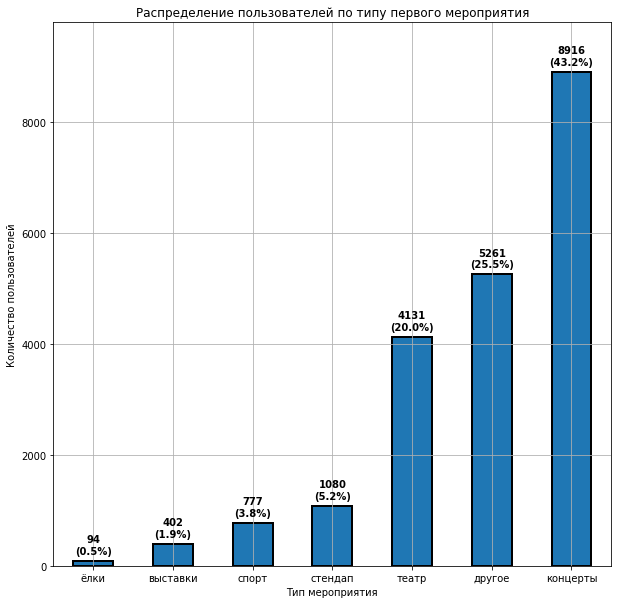

In [55]:
# Столбчатая диаграмма для типов первого мероприятия
barplot_of_series(
    df_profile_genre_first, 
    "Распределение пользователей по типу первого мероприятия",
    "Тип мероприятия",
    "Количество пользователей",
    vert=True
)

Исходя из полученного графика, можно сделать вывод, что тип первого мероприятия распределён неравномерно. Самыми большими сегментами у первого посещённого мероприятия пользователями являются **"концерты"**, **"другое"** и **"театры"** с количествами пользователей **8916 (43.2%)**, **5291 (25.5%)** и **4131 (20.0%)** соответственно. Остальные сегменты намного меньше, а самым маленьким сегментов является посещение мероприятия с типом **"ёлки"** с **94 пользователями** в сегменте, что составляет **0.5% от общего числа пользователей**.

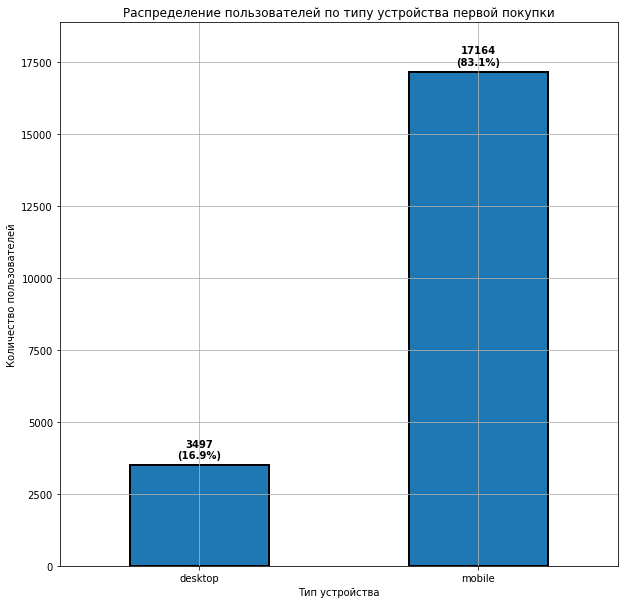

In [56]:
# Столбчатая диаграмма для типов устройства первой покупки
barplot_of_series(
    df_profile_device_first, 
    "Распределение пользователей по типу устройства первой покупки",
    "Тип устройства",
    "Количество пользователей",
    vert=True
)

Как видно из графика большая часть пользователей (**17164 пользователя**, что составляет **83.1% от общего числа**) совершило свой первый заказ с мобильного устройства, а остальные 3497 пользователей (16.9%) делали свой первый заказ со стационарного устройства. Распределение значений не является равномерным, а ярко выражена тенденция на первый заказа с мобильных устройств.

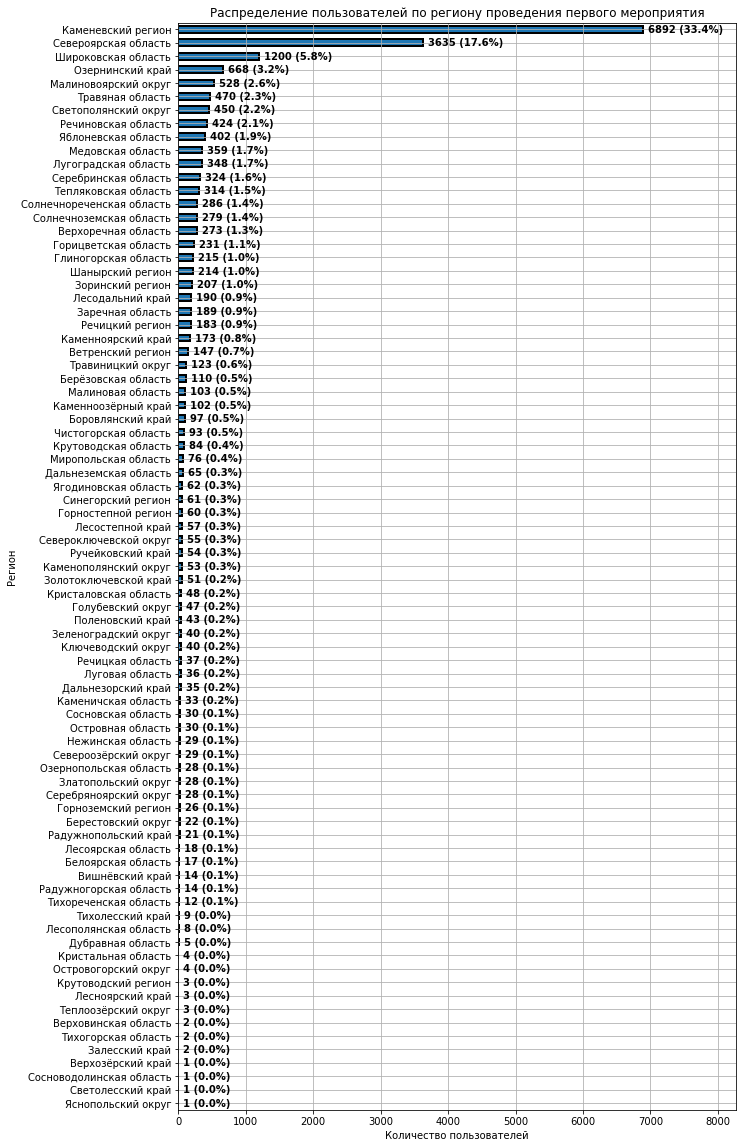

In [57]:
# Столбчатая диаграмма для регионов проведения первого мероприятия
barplot_of_series(
    df_profile_region_first, 
    "Распределение пользователей по региону проведения первого мероприятия",
    "Регион",
    "Количество пользователей",
    vert=False,
    figsize=(10, 20)
)

Из графика видно, что распределение количества пользователей по сегментам региона проведения первого мероприятия не является равномерным. Наблюдаются наибольшие сегменты для пользователей, чьи первые мероприятия проходили в регионах **"Каменевский регион"** и **"Североярская область"** с количествами пользователей **6892 (33.4%)** и **3635 (17.6%)**, эти сегменты составляют половину от общего числа пользователей. Самыми маленькими сегментами являются регионы **"Верхозёрский край"**, **"Сосноводолинская область"**, **"Светолесский край"** и **"Яснопольский округ"**, каждому из которых соответствует только **один пользователь**, что составляет **меньше одной сотой процента всех пользвоателей**.

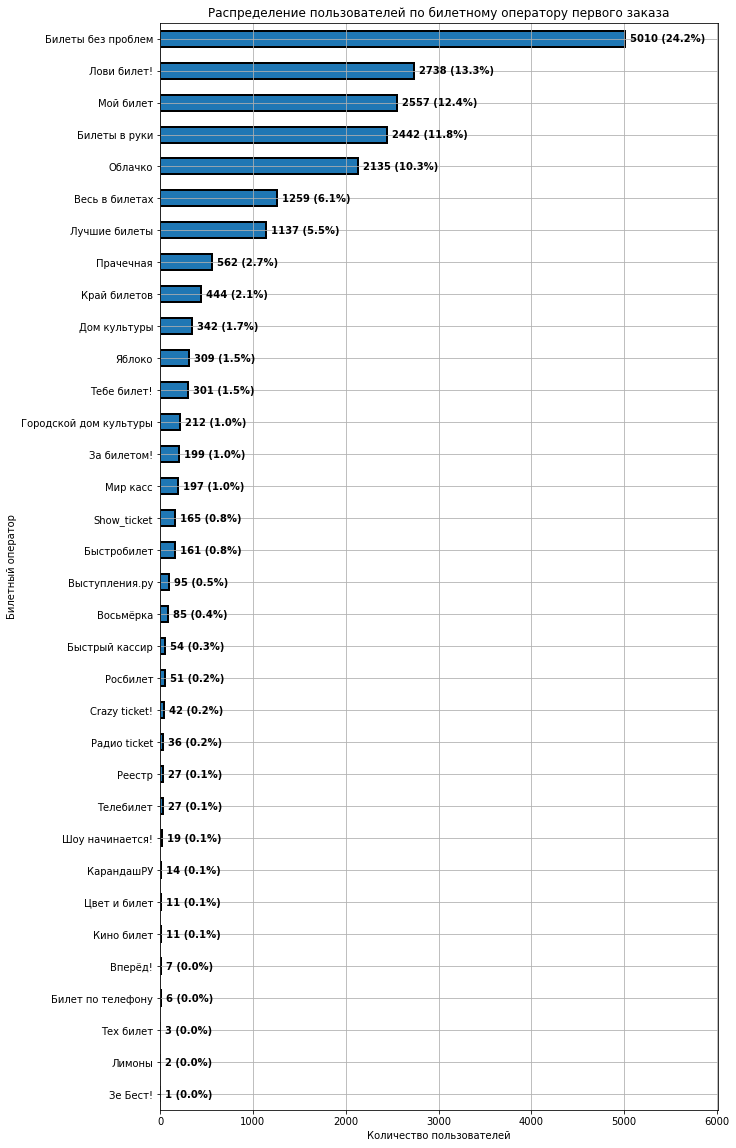

In [58]:
# Столбчатая диаграмма для билетных операторов первого заказа
barplot_of_series(
    df_profile_service_first, 
    "Распределение пользователей по билетному оператору первого заказа",
    "Билетный оператор",
    "Количество пользователей",
    vert=False,
    figsize=(10, 20)
)

Распределение по категориям билетного оператора первого заказа также не является равномерным. Самым популярным оператором является "Билеты без проблем", которому соответствует **5010 пользователей (24.2%)**. Также стоит отметить операторов **"Лови билет!"**, **"Мой билет"**, **"Билеты в руки"** и **"Облачко"**, к которым во время первого заказа обратилось **2738 (13.3%)**, **2557 (12.4%)**, **2442 (11.8%)** и **2135 (10.3%)** пользователей соответственно.
Присутсвует много билетных операторов, для которых характерно очень малой количество пользователей, обратившихся к ним в первый раз. Самыми непопулярными для первой покупки билетов операторами являются **"Зе Бест!"**, **"Лимоны"** и **"Тех билет"**, которыми воспользовались 1, 2 и 3 пользователя соответственно.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Вычисляем среднюю долю пользователей, совершающих повторный заказ, по всей выборке.

In [59]:
print(f"Средняя доля пользователей, соверщающих повторный заказ: {format(df_profile['is_two'].mean(), '0.1%')}")

Средняя доля пользователей, соверщающих повторный заказ: 59.8%


In [60]:
# Фильтрация датафрейма, оставляющая только пользователей совершивших 2 и более покупки
df_profile_filt_is_two = df_profile[df_profile["is_two"]]

In [61]:
# Группировка пользователей по типу первого мероприятия
df_profile_genre_is_two = df_profile_filt_is_two.groupby("genre_first")[["is_two"]].count()

# Группировка пользователей по типу первого устройства
df_profile_device_is_two = df_profile_filt_is_two.groupby("device_first")[["is_two"]].count()

# Группировка пользователей по региону первого заказа
df_profile_region_is_two = df_profile_filt_is_two.groupby("region_first")[["is_two"]].count()

# Группировка пользователей по оператору первого заказа
df_profile_service_is_two = df_profile_filt_is_two.groupby("service_first")[["is_two"]].count()

In [62]:
# Добавление информации о количестве людей в целом сегменте к каждому датафрейму

df_profile_genre_is_two["total"] = df_profile_genre_first
df_profile_device_is_two["total"] = df_profile_device_first
df_profile_region_is_two["total"] = df_profile_region_first
df_profile_service_is_two["total"] = df_profile_service_first

In [63]:
# Вычисление доли пользователей, совершивших два и более заказа
df_profile_genre_is_two["prop"] = df_profile_genre_is_two["is_two"] / df_profile_genre_is_two["total"]
df_profile_device_is_two["prop"] = df_profile_device_is_two["is_two"] / df_profile_device_is_two["total"]
df_profile_region_is_two["prop"] = df_profile_region_is_two["is_two"] / df_profile_region_is_two["total"]
df_profile_service_is_two["prop"] = df_profile_service_is_two["is_two"] / df_profile_service_is_two["total"]

Выводим столбчатые диаграммы для распределений доли пользователей, совершивших два и более заказа, для каждой круппировки пользователей. Каждый датафрейм сначала сортируем по убыванию общего количества пользователей в сегментах и оставляем только первые 10 строк, а после сортируем по доле пользователей.

In [64]:
# Функция для отрисовки столбчатой диаграммы с долями
def barplot_of_df_for_prop(
    df:pd.DataFrame,
    title:str, 
    xlabel:str, 
    ylabel:str,
    prop_col:str="prop",
    total_count_col:str="total",
    vert:bool=True, 
    percent_format:str="0.01%", 
    figsize:tuple[float, float]=(10, 10)
    
):    
    # Столбчатая диаграмма для категорий в столбце
    plot = df[prop_col].plot(
        kind="bar" if vert else "barh",
        grid=True,
        title=title,
        xlabel=xlabel if vert else ylabel,
        ylabel=ylabel if vert else xlabel,
        figsize=figsize,
        linewidth=2,
        edgecolor="black",
        rot=0,
    )
    
    # Список кортежей из двух столбцов
    cols = list(zip(df[prop_col], df[total_count_col]))
    
    # Разделитель между долей и общим количеством
    sep = '\n' if vert else ' '
    
    # Добавление подписей к столбцам
    plot.bar_label(
        plot.containers[0], 
        labels=[f"{format(row[0], percent_format)}{sep}({row[1]})" for row in cols],
        padding=5,
        fontweight='bold'
    )
    
    # Если вертикальная, то отсуп сверху, иначе - отсуп справа
    if vert:
        plot.set_ylim(0, df[prop_col].max() * 1.1)
    else:
        plot.set_xlim(0, df[prop_col].max() * 1.2)
    
    plt.show()

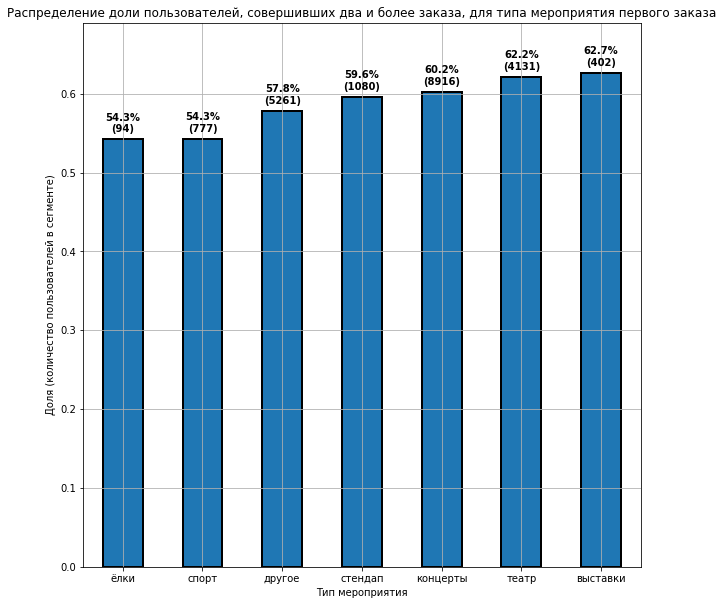

In [65]:
# Столбчатая диаграмма долей пользователей, совершивших два и более заказа, для типа мероприятия
barplot_of_df_for_prop(
    df_profile_genre_is_two.sort_values("total", ascending=False).head(10).sort_values("prop"),
    "Распределение доли пользователей, совершивших два и более заказа, для типа мероприятия первого заказа",
    "Тип мероприятия",
    "Доля (количество пользователей в сегменте)"
)

В распределении доли пользователей для типа мероприятия первого заказа нет ярко выраженных максимальных значений доли пользователей. Успешными точками входа по типу первого мероприятия могут считаться сегменты **"выставки"**, **"театр"** и **"концерты"** в которых доли пользвоателей, сделавших повторный заказ, равны **62.7%**, **62.2%** и **60.2%** соответственно. Однако, **наибольшую стабильность показывают точки входа "концерты" и "театр"**, в которые попадают **8916** и **4131** пользователей, в то время как в сегменте "выставки" находится только 402 пользователя.

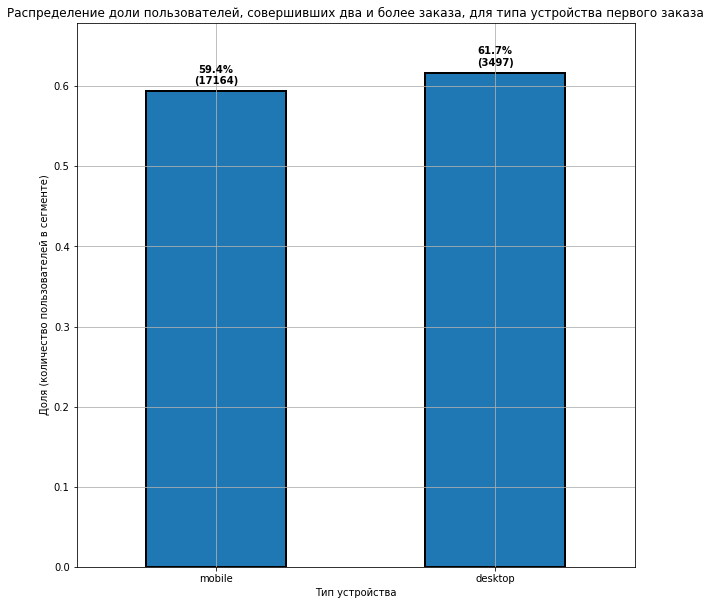

In [66]:
# Столбчатая диаграмма долей пользователей, совершивших два и более заказа, для типа устройства
barplot_of_df_for_prop(
    df_profile_device_is_two.sort_values("total", ascending=False).head(10).sort_values("prop"),
    "Распределение доли пользователей, совершивших два и более заказа, для типа устройства первого заказа",
    "Тип устройства",
    "Доля (количество пользователей в сегменте)"
)

Распределение доли пользователей, совершивших два и более заказов, при группировке по типам устройств, с которых была совершена первая покупка, является примерно равномерной. Для сегмента мобильных устройств доля возвращающихся пользователей равна **59.4%**, а для стационарных - **61.7%**. Ярко выраженных успешных точек входа не наблюдается, так как обе доли находятся очень близко к средней доле по выборке (59.8%).

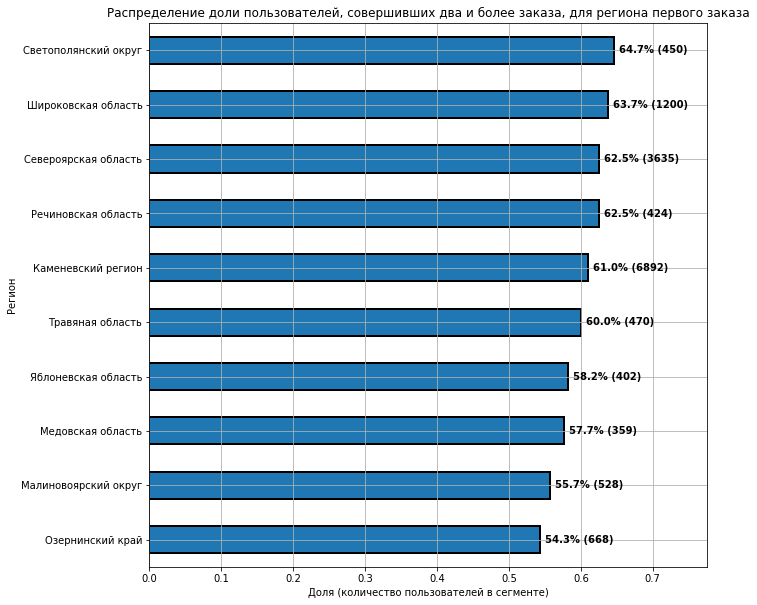

In [67]:
# Столбчатая диаграмма долей пользователей, совершивших два и более заказа, для региона
barplot_of_df_for_prop(
    df_profile_region_is_two.sort_values("total", ascending=False).head(10).sort_values("prop"),
    "Распределение доли пользователей, совершивших два и более заказа, для региона первого заказа",
    "Регион",
    "Доля (количество пользователей в сегменте)",
    vert=False
)

При группировке по региону первого заказа, успешными точками входа являются регионы **"Светополянский округ" (64.7%)**, **"Широковская область" (63.7%)**, **"Североярская область" (62.5%)**, **"Речиновская область" (62.5%)**, **"Каменевский регион" (61%)** и **"Травяная область" (60%)**. Наибольшее число первых заказов наблюдается в успешных точках входа **"Каменевский регион"** и **"Североярская область"**, в сегменты которых попадает **6892** и **3635** пользователей соответственно.

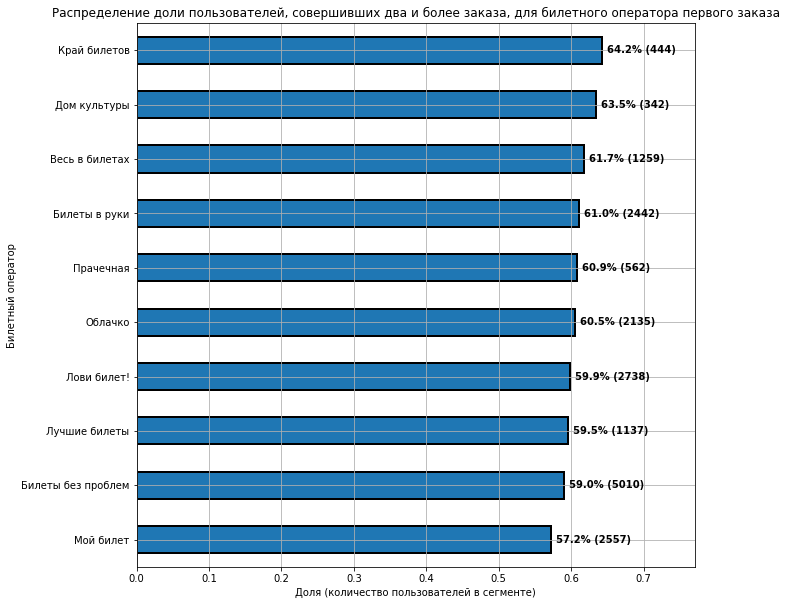

In [68]:
# Столбчатая диаграмма долей пользователей, совершивших два и более заказа, для билетного оператора
barplot_of_df_for_prop(
    df_profile_service_is_two.sort_values("total", ascending=False).head(10).sort_values("prop"),
    "Распределение доли пользователей, совершивших два и более заказа, для билетного оператора первого заказа",
    "Билетный оператор",
    "Доля (количество пользователей в сегменте)",
    vert=False
)

Исходя из графика распределения доли пользователей, совершивших 2 и более заказа, по билетному оператору по первого заказа, можно сделать вывод что успешными точками входа являются билетные операторы **"Край билетов" (64.2%)**, **"Дом культуры" (63.5%)**, **"Весь в билетах" (61.7%)**, **"Билеты в руки" (61%)**, **"Прачечная" (60.9%)** и **"Облачко" (60.5%)**, из которых наибольшее количество пользователей, совершивших у этого билетного оператора первй заказ, наблюдается у **"Билеты в руки"** и **"Облачко"** с **2442** и **2135** пользователями соответственно.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1**

Сравним доли возвращающихся пользователей для сегментов мероприятий "спорт" и "концерты".

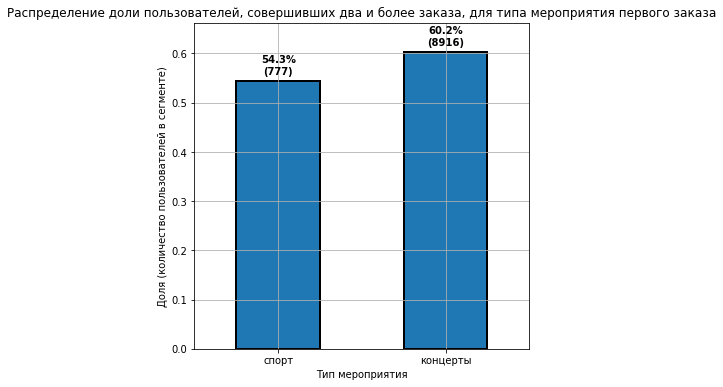

In [69]:
# Столбчатая диаграмма долей пользователей, совершивших два и более заказа, для мероприятий типов "концерты" и "спорт"
barplot_of_df_for_prop(
    df_profile_genre_is_two.loc[["спорт", "концерты"]],
    "Распределение доли пользователей, совершивших два и более заказа, для типа мероприятия первого заказа",
    "Тип мероприятия",
    "Доля (количество пользователей в сегменте)",
    figsize=(6, 6)
)

Из полученной столбчатой диаграммы видно, что доля пользователей, возвращающихся после первой покупки билета на спортивное мероприятие, меньше чем возвращающихся после первой покупки билета на концерты. Следовательно **гипотеза 1 не является верной**.

**Гипотеза 2**

In [70]:
# Создаём датафрейм содержащий количества уникальных пользователей в каждом регионе
# и сортируем его по возрастанию количества

df_region_count_users = df.groupby("region_name")[["user_id"]].nunique()
df_region_count_users = df_region_count_users.sort_values("user_id")
df_region_count_users.head()

,user_id
region_name,
Теплоозёрский округ,5
Верхозёрский край,5
Сосноводолинская область,7
Лесноярский край,10
Яснопольский округ,11


In [71]:
# Добавляем в датафрейм информацию о доле возвращающихся пользователей
df_region_count_users = df_region_count_users.merge(df_profile_region_is_two["prop"], left_index=True, right_index=True)
df_region_count_users.head()

,user_id,prop
Теплоозёрский округ,5,0.333333
Верхозёрский край,5,1.000000
Лесноярский край,10,0.666667
Крутоводский регион,11,0.333333
Тихогорская область,24,0.500000


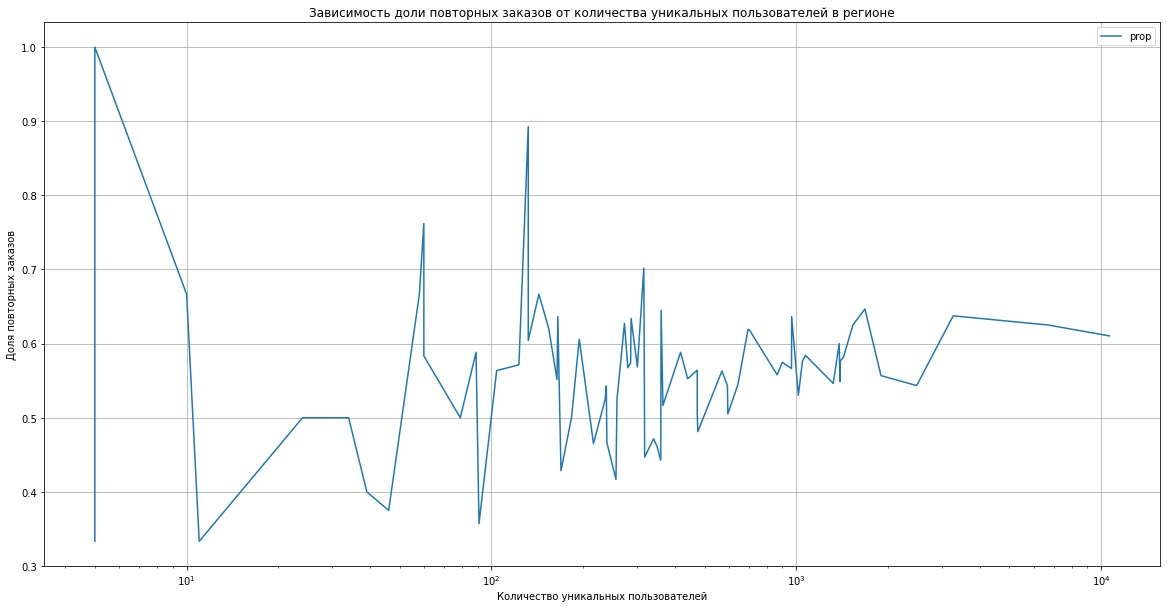

In [72]:
# Отрисовка линейного графика зависимости количества людей
# Используем логарифмическую шкалу для количества пользователей,
# чтобы график не был сжат в начале оси
df_region_count_users.plot(
    kind="line", 
    x="user_id", 
    y="prop",
    figsize=(20, 10),
    logx=True,
    grid=True,
    title="Зависимость доли повторных заказов от количества уникальных пользователей в регионе",
    xlabel="Количество уникальных пользователей",
    ylabel="Доля повторных заказов"
)

plt.show()

Из данного графика видно, что доля возвращающихся пользователей не зависит от количества пользователей посещающих мероприятия. Следовательно **гипотеза 2 не является верной**.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [73]:
# Создание датафрейма, содержащего пользователей совершивших 1 заказ
df_profile_is_one = df_profile[df_profile["count_orders"] == 1]

# Создание датафрейма, содержащего пользователей совершивших 2 и более заказов
df_profile_is_two = df_profile[df_profile["is_two"]]

In [74]:
# Функция для отрисовки двух гистограмм на одном холсте

def hist_of_two_series(
    series1:pd.Series, 
    series2:pd.Series,
    num_bins:int,
    title:str,
    xlabel:str,
    histlabel1:str,
    histlabel2:str,
    figsize:tuple[float, float]
):
    # Создаём бины, учитывая границы обеих серий, чтобы столбцы имели одинаковую ширину в обеих гистограммах
    bin_edges = np.linspace(min(series1.min(), series2.min()), max(series1.max(), series2.max()), num_bins+1)

    plt.figure(figsize=figsize)

    # Гистограмма распределения значений первой серии
    plt.hist(
        series1,
        bins=bin_edges,
        label=histlabel1,
        edgecolor="black",
        density=True,
        alpha=0.5
    )

    # Гистограмма распределения значений второй серии
    plt.hist(
        series2,
        bins=bin_edges,
        label=histlabel2,
        edgecolor="black",
        density=True,
        alpha=0.5
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid()
    plt.show()

In [75]:
desc1 = df_profile_is_one['avg_revenue'].describe()
desc2 = df_profile_is_two['avg_revenue'].describe()
print(f"Статистические показатели средней выручки пользователей, совершивших 1 заказ:\n{desc1}")
print(f"\n\nСтатистические показатели средней выручки пользователей, совершивших 2 заказа и более:\n{desc2}")

Статистические показатели средней выручки пользователей, совершивших 1 заказ:
count     8312.000000
mean       570.937711
std        633.656072
min        -10.770000
25%        139.602500
50%        384.495000
75%        835.630000
max      14913.530000
Name: avg_revenue, dtype: float64


Статистические показатели средней выручки пользователей, совершивших 2 заказа и более:
count    12349.000000
mean       578.671224
std        500.763946
min         -5.385000
25%        269.075000
50%        500.940000
75%        778.105333
max      16738.696667
Name: avg_revenue, dtype: float64


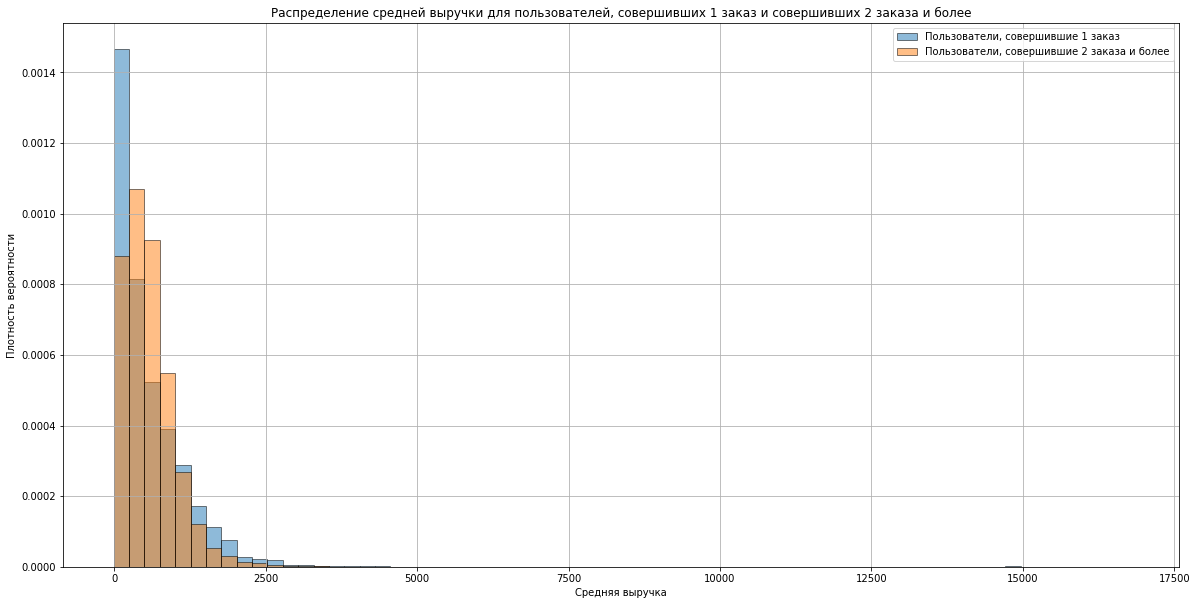

In [76]:
# Отрисовка гистограмм для распределений выручки пользователей из двух групп
hist_of_two_series(
    df_profile_is_one['avg_revenue'],
    df_profile_is_two['avg_revenue'],
    66,
    "Распределение средней выручки для пользователей, совершивших 1 заказ и совершивших 2 заказа и более",
    "Средняя выручка",
    "Пользователи, совершившие 1 заказ",
    "Пользователи, совершившие 2 заказа и более",
    (20, 10)
)

Обе группы пользователей имеют примерно одинаковую ожидаемую среднюю выручку - **570 рублей** для совершивших 1 заказ и **578 рублей** для совершивших 2 заказа и более. Однако пользователей совершивших 2 и более покупок **в 1.5 раза больше** чем совершивших только 1 покупку. Также различие в группах наблюдается в том, что **пользователи из первой группы чаще делают дешёвые заказы (до 250 рублей) и заказы от 1000 рублей** чем пользователи из второй группы.

По полученной гистограмме можно увидеть, пользователи из первой группы концентрируются в диапазоне **от 0 до 250 рублей**, а пользователи из второй группы в диапазоне **от 250 до 750 рублей**.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [77]:
# Создание датафрейма, содержащего пользователей совершивших от 2 до 4 заказов
df_profile_is_two_four = df_profile_is_two[~df_profile_is_two["is_five"]]

# Создание датафрейма, содержащего пользователей совершивших от 5 заказов
df_profile_is_five = df_profile[df_profile["is_five"]]

In [78]:
desc1 = df_profile_is_two_four['avg_revenue'].describe()
desc2 = df_profile_is_five['avg_revenue'].describe()
print(f"Статистические показатели средней выручки пользователей, совершивших 2-4 заказа:\n{desc1}")
print(f"\n\nСтатистические показатели средней выручки пользователей, совершивших от 5 заказов:\n{desc2}")

Статистические показатели средней выручки пользователей, совершивших 2-4 заказа:
count     7082.000000
mean       580.886519
std        564.093509
min         -5.385000
25%        225.678750
50%        474.220000
75%        810.685000
max      16738.696667
Name: avg_revenue, dtype: float64


Статистические показатели средней выручки пользователей, совершивших от 5 заказов:
count    5267.000000
mean      575.692541
std       400.145768
min         0.000000
25%       326.106500
50%       522.662857
75%       747.117375
max      8514.866250
Name: avg_revenue, dtype: float64


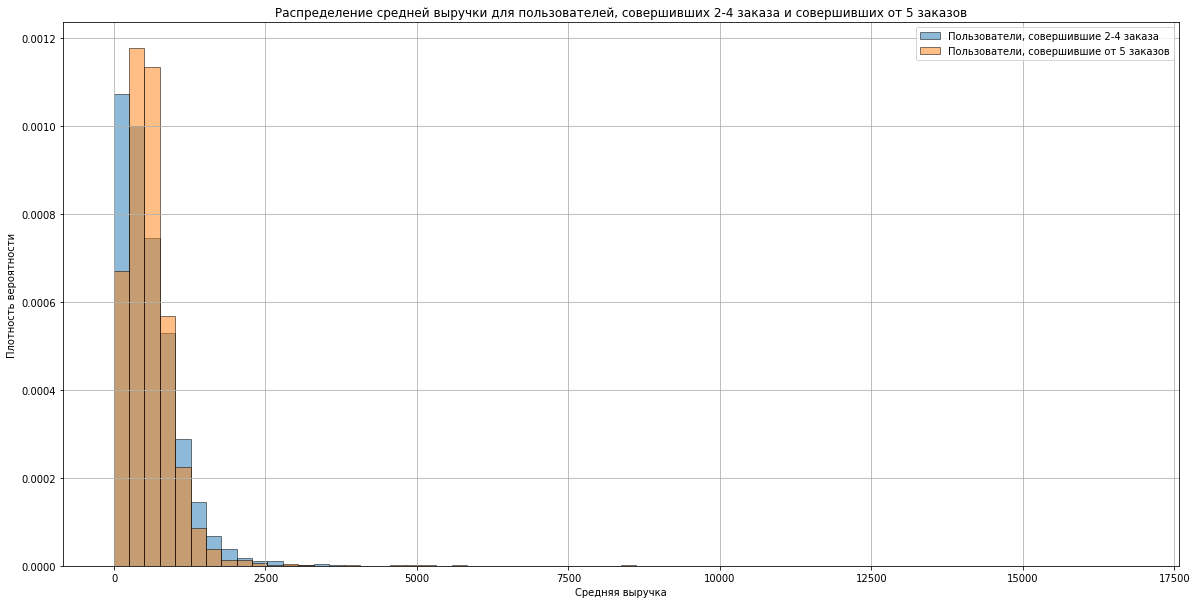

In [79]:
# Отрисовка гистограмм для распределений выручки пользователей из двух групп
hist_of_two_series(
    df_profile_is_two_four['avg_revenue'],
    df_profile_is_five['avg_revenue'],
    66,
    "Распределение средней выручки для пользователей, совершивших 2-4 заказа и совершивших от 5 заказов",
    "Средняя выручка",
    "Пользователи, совершившие 2-4 заказа",
    "Пользователи, совершившие от 5 заказов",
    (20, 10)
)

Ожиданемая средняя выручка пользователей, совершивших 2-4 заказа (первая группа), не сильно отличается от ожидаемой средней выручки, совершивших от 5 заказов (вторая группа) - для первой группы равно **580 рублям**, а для второй - **575 рублей**.

Исходя из полученной гистограммы, можно сделать вывод, что между рассматриваемыми группами есть различия по значению средней выручки. Пользователи из первой группы чаще чем пользователи из второй группы делают заказы **до 250 и от 1000 рублей**, а пользователи из второй группы делают чаще заказы **от 250 до 1000 рублей**.

Можно заметить, что полученные распределения внешне очень похожи на распределения групп пользователей, совершивших 1 заказ и совершивших 2 заказа и более. Можно предположить, что при сравнении любых двух групп пользователей с разным количеством заказов, пользователи из группы, имеющей меньшее количество заказов, будут чаще приносить маленькую среднюю выручку или большую среднюю выручку, чем пользователи из другой группы.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [80]:
desc = df_profile["avg_tickets"].describe()
print(f"Статистические показатели среднего количества билетов в заказе:\n{desc}")

Статистические показатели среднего количества билетов в заказе:
count    20661.000000
mean         2.753519
std          0.947179
min          1.000000
25%          2.000000
50%          2.777778
75%          3.200000
max         12.000000
Name: avg_tickets, dtype: float64


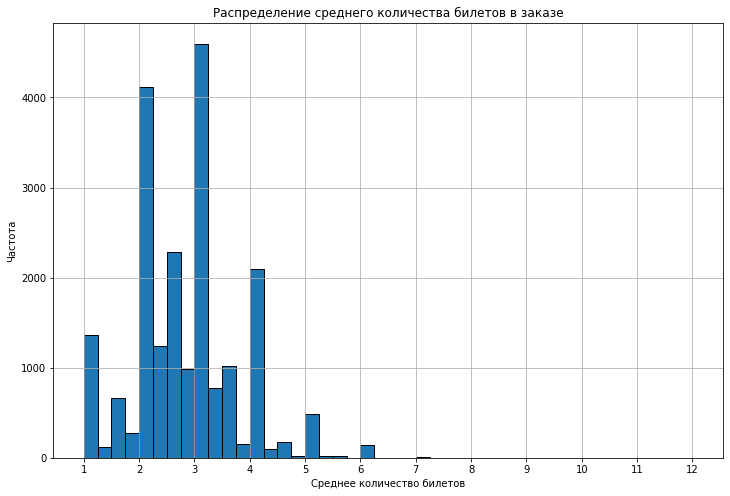

In [81]:
# Отрисовка гистограммы распределения среднего количества билетов в заказе.
df_profile["avg_tickets"].plot(
    kind="hist",
    edgecolor="black",
    figsize=(12, 8),
    bins=44,
    title="Распределение среднего количества билетов в заказе",
    xlabel="Среднее количество билетов",
    ylabel="Частота",
    grid=True
)
# Задаём тики на оси x вручную, чтобы насечки были на каждом целом числе
plt.xticks(np.arange(1, 13, 1))
plt.show()

В полученной гистограмме распределения среднего количества билетов можно заметить **локальные максимумы в точках, соответствующих целому среднему числу заказов**. Данное наблюдение можно объяснить тем, что значительная часть пользователей (8312 человек) **делали только один заказ**, и их среднее не может быть нецелым числом.

Также наблюдается **концентрация среднего количества билетов в основном в диапазоне от 2 до 3 билетов**, можно предположить, что это связано с тем, что пользователи **предпочитают посещать мероприятия с близкими людьми**, а не большими компаниями.

In [82]:
# Создание датафреймов, содержащих пользователей с разными средними количествами заказов.
df_profile_tickets_one_two = df_profile[df_profile["avg_tickets"] < 2]
df_profile_tickets_two_three = df_profile[(df_profile["avg_tickets"] >= 2) & (df_profile["avg_tickets"] < 3)]
df_profile_tickets_three_five = df_profile[(df_profile["avg_tickets"] >= 3) & (df_profile["avg_tickets"] < 5)]
df_profile_tickets_more_five = df_profile[df_profile["avg_tickets"] >= 5]

In [83]:
print(
    f"""
Сегмент от 1 до 2 билетов:
    Число пользователей: {df_profile_tickets_one_two.shape[0]}
    Доля пользователей совершивших повторные заказы: {format(df_profile_tickets_one_two["is_two"].mean(), '0.1%')}""")

print(
    f"""
Сегмент от 2 до 3 билетов:
    Число пользователей: {df_profile_tickets_two_three.shape[0]}
    Доля пользователей совершивших повторные заказы: {format(df_profile_tickets_two_three["is_two"].mean(), '0.1%')}""")

print(
    f"""
Сегмент от 3 до 5 билетов:
    Число пользователей: {df_profile_tickets_three_five.shape[0]}
    Доля пользователей совершивших повторные заказы: {format(df_profile_tickets_three_five["is_two"].mean(), '0.1%')}""")

print(
    f"""
Сегмент от 5 билетов:
    Число пользователей: {df_profile_tickets_more_five.shape[0]}
    Доля пользователей совершивших повторные заказы: {format(df_profile_tickets_more_five["is_two"].mean(), '0.1%')}""")


Сегмент от 1 до 2 билетов:
    Число пользователей: 2420
    Доля пользователей совершивших повторные заказы: 50.7%

Сегмент от 2 до 3 билетов:
    Число пользователей: 8620
    Доля пользователей совершивших повторные заказы: 71.3%

Сегмент от 3 до 5 билетов:
    Число пользователей: 8933
    Доля пользователей совершивших повторные заказы: 54.2%

Сегмент от 5 билетов:
    Число пользователей: 688
    Доля пользователей совершивших повторные заказы: 19.3%


**Пользователи распределены по сегментам неравномерно** - в сегментах от 2 до 3 билетов и от 3 до 5 билетов находится **8620** и **8933** пользователей соответственно, в то время как в сегментах от 1 до 2 билетов и от 5 билетов находится **2420** и **688** пользователей.

В сегментах с бОльшим количество пользователей наблюдается бОльшая доля пользователей, совершающих повторный заказ. Можно сказать, что **самой успешной точкой входа является сегмент от 2 до 3 билетов**, ведь в нём **71% пользователей возвращаются** в сервис, а **самой неудачной точкой входа - сегмент от 5 билетов**, **доля возвращающихся пользователей в котором составляет 19%**.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [84]:
# Расчёт дня недели первой покупки пользователя
df_profile["day_of_week_first"] = df_profile["dt_first"].dt.day_of_week

# Расчёт лайфтайма пользователя
df_profile["lifetime"] = (df_profile["dt_last"] - df_profile["dt_first"])
# Преобразование лайфтайма в число (количество дней)
df_profile["lifetime"] = df_profile["lifetime"].dt.days

df_profile.head()

,user_id,dt_first,dt_last,device_first,region_first,service_first,genre_first,count_orders,avg_revenue,avg_tickets,avg_days_between,is_two,is_five,day_of_week_first,lifetime
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False,1,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False,1,75
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False,5,102
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False,3,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False,6,16


In [85]:
# Группируем данные по дню недели первого заказа и вычисляем число пользователей и долю вернувшихся пользователей
df_profile_day_of_week_first = df_profile.groupby("day_of_week_first").agg(
    count_users=("user_id", "count"),
    prop_returned=("is_two", "mean"),
)

df_profile_day_of_week_first

,count_users,prop_returned
day_of_week_first,,
0,2763,0.615273
1,2941,0.597416
2,2939,0.607690
3,3040,0.588158
4,3193,0.589101
5,3130,0.603834
6,2655,0.582674


In [86]:
# Замена числового представления дней недели на строковое для удобства отображения на графике
day_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}
df_profile_day_of_week_first_str = df_profile_day_of_week_first.rename(index=day_names)
df_profile_day_of_week_first_str

,count_users,prop_returned
day_of_week_first,,
Понедельник,2763,0.615273
Вторник,2941,0.597416
Среда,2939,0.607690
Четверг,3040,0.588158
Пятница,3193,0.589101
Суббота,3130,0.603834
Воскресенье,2655,0.582674


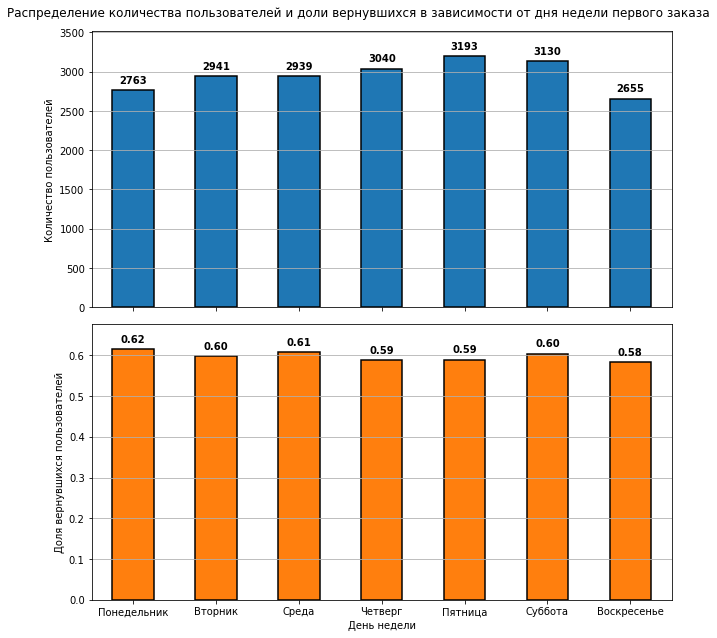

In [87]:
# Распределение количества пользователей в зависимости от дня недели первого заказа
plot = df_profile_day_of_week_first_str.plot(
    kind="bar",
    edgecolor="black",
    linewidth=1.5,
    title="Распределение количества пользователей и доли вернувшихся в зависимости от дня недели первого заказа",
    xlabel="День недели",
    rot=0,
    figsize=(9, 9),
    subplots=True,
    sharex=True,
    legend=False
)

# Удаление названий для отедальных графиков, так ка киспользуется общее название
plot[0].set_title("")
plot[1].set_title("")

# Добавление подписей к осям y
plot[0].set_ylabel("Количество пользователей")
plot[1].set_ylabel("Доля вернувшихся пользователей")

# Добавление сетки по оси y
plot[0].grid(axis="y")
plot[1].grid(axis="y")

# Добавление подписей на первый график
plot[0].bar_label(
        plot[0].containers[0], 
        labels=[f"{i}" for i in df_profile_day_of_week_first_str["count_users"]],
        padding=5,
        fontweight='bold'
    )

# Добавление подписей на второй график
plot[1].bar_label(
        plot[1].containers[0], 
        labels=[format(i, "0.2f") for i in df_profile_day_of_week_first_str["prop_returned"]],
        padding=5,
        fontweight='bold'
    )

# Увеличение оси y для того, чтобы подписи к столбцам не заходили за график
plot[0].set_ylim(0, df_profile_day_of_week_first_str["count_users"].max() * 1.1)
plot[1].set_ylim(0, df_profile_day_of_week_first_str["prop_returned"].max() * 1.1)

plt.tight_layout()

plt.show()

Из графика распределения доли вернувшихся пользователей видно, что **размер доли примерно равномерно распределена по всем дням недели**, следовательно можно сделать вывод, что **день недели первого заказа не оказывается влияния на возврат пользователя** к использованию сервиса.

Также в графика распределения количества пользователей можно заметить, что **количество первых покупок почти монотонно растёт от понедельника к пятнице**, а в выходные оно наоборот снижается. Это можно объяснить тем, что **пользователи покупают билеты заранее перед выходными**, на которых они собираются посетить мероприятие.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [88]:
# Среднее время между заказами для пользователей совершивших 2-4 заказа
avg1 = df_profile_is_two_four['avg_days_between'].mean()
# Среднее время между заказами для пользователей совершивших 5 и более заказов
avg2 = df_profile_is_five['avg_days_between'].mean()

print(f"Среднее время между заказами для пользователей совершивших 2-4 заказа: {format(avg1, '0.1f')}")
print(f"Среднее время между заказами для пользователей совершивших 5 и более заказов: {format(avg2, '0.1f')}")

Среднее время между заказами для пользователей совершивших 2-4 заказа: 21.4
Среднее время между заказами для пользователей совершивших 5 и более заказов: 11.1


Среднее время между заказами для пользователей совершивших 2-4 заказа **почти в 2 раза больше** чем для пользователей совершивших от 5 и более заказов.

Исходя из полученных значений среднего времени между заказами можно предположить, что **чем меньше интервал времени между заказами у пользователя, тем выше его количество заказов в общем**. Проверим эту гипотезу.

In [89]:
# Фильтрация профилей пользователей
# Оставляем только имеющих 2 и более заказа, так как для других пользователей интервал между заказами непоределён
df_profile_with_round = df_profile[df_profile["is_two"]].copy()

In [90]:
# Создание нового столбца для хранения округлённого значения среднего интервала между заказами
# Округление происходит для того, чтобы сгруппировать пользователей
df_profile_with_round["avg_days_between_round"] = df_profile_with_round["avg_days_between"].round()

In [91]:
# Группировка пользователей по округлённому среденему интервалу между заказами
# Для каждой группы вычислется среднее количество заказов пользователей
df_profile_with_round_grouped = df_profile_with_round.groupby("avg_days_between_round")["count_orders"].mean()

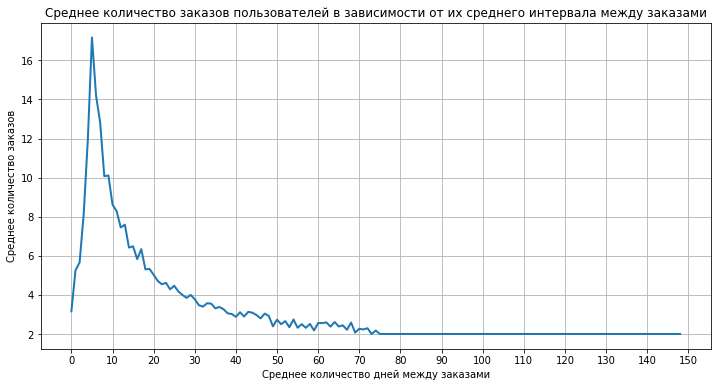

In [92]:
# Отрисовка графика зависимости среднего количества заказов пользователей в зависимости от их среднего интервала между заказами
df_profile_with_round_grouped.plot(
    kind="line",
    title="Среднее количество заказов пользователей в зависимости от их среднего интервала между заказами",
    xlabel="Среднее количество дней между заказами",
    ylabel="Среднее количество заказов",
    figsize=(12, 6),
    linewidth=2,
    grid=True
)

# Задаём тики на оси x вручную, чтобы насечки были на каждом десятке
plt.xticks(np.arange(0, 151, 10))

plt.show()

По полученному графику видно что при **среднем интервале от 0 до 5 график резко возрастает до 16.5 заказов** в среднем, но **при значении среднего интервала от 5 на графике наблюдается постепенное падение до 2 заказов** в среднем. Следовательно **данная гипотеза доказана** с оговорками, что работает она для интервала между заказами от 5 дней.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [93]:
# Убираем столбец с id пользователя и производные столбцы от count_orders
df_profile_for_corr = df_profile.drop(["user_id", "is_two", "is_five"], axis=1)

In [94]:
# Функция для построения и вывода матрицы корреляций
def create_corr_matrix_one_col(
    df: pd.DataFrame, 
    col:str
):
    # Матрица корреляций для всего датафрейма
    corr_matrix = df.phik_matrix()

    # Оставляем только столбец соответствующий заданному столбцу и убираем соответствующую строку
    corr_matrix = corr_matrix[[col]][corr_matrix.index != col]
    print(f"Матрица корреляций для столбца {col}:\n{corr_matrix}")
    
    # Тепловая карта полученной матрицы коррелций
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        linewidths=1,
        cmap="coolwarm",
    )
    plt.title("Тепловая карта для матрицы корреляций")
    plt.show()
    

In [95]:
# Убираем столбец с id пользователя и производные столбцы от count_orders
df_profile_for_corr = df_profile.drop(["user_id", "is_two", "is_five"], axis=1)

interval columns not set, guessing: ['count_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between', 'day_of_week_first', 'lifetime']
Матрица корреляций для столбца count_orders:
                   count_orders
dt_first               0.387454
dt_last                0.393971
device_first           0.023558
region_first           0.000000
service_first          0.045313
genre_first            0.029773
avg_revenue            0.053752
avg_tickets            0.315359
avg_days_between       0.468725
day_of_week_first      0.000000
lifetime               0.658623


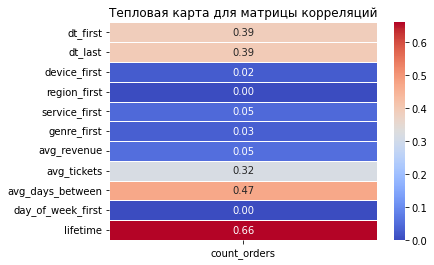

In [96]:
create_corr_matrix_one_col(df_profile_for_corr, "count_orders")

Исходя из полученной матрциы корреляций можно сделать вывод, что **количество заказов пользователя сильно зависит от его лайфтайма** (коэффициент корреляции 0.66), то есть чем больше интервал между его первой и последней покупкой, тем больше вероятность, что он делает много заказов. Также наблюдается **высокая корреляция со средним количеством дней между заказами пользователя** (коэффициент корреляции 0.47), данная зависимость была доказана в задаче 4.3.2.

Со столбцами, содержащими дату первой и последней покупок, также наблюдается корреляция с коэффициентом 0.39, но данная зависимость объясняется тем, что сильно влияющий столбец c лайфтаймом является производным от данных двух столбцов.

Визуализируем найденные сильные корреляции.

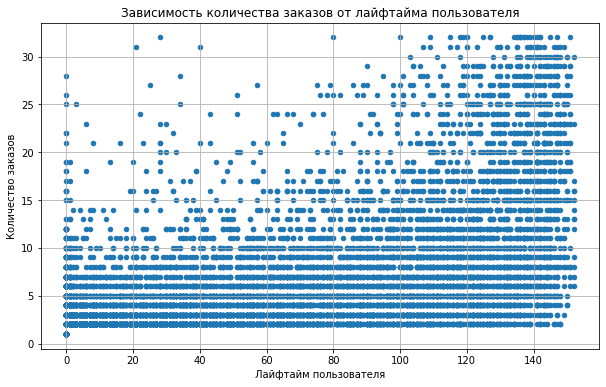

In [142]:
# График зависимости количества заказов от лайфтайма пользователя
df_profile.plot(
    kind="scatter",
    x="lifetime",
    y="count_orders",
    title="Зависимость количества заказов от лайфтайма пользователя",
    xlabel="Лайфтайм пользователя",
    ylabel="Количество заказов",
    figsize=(10, 6),
    grid=True
)
plt.show()

На данном графике видно, что, чем больше лайфтайм пользователя, тем больше вероятность того, что пользователь имеет большое количество заказов.

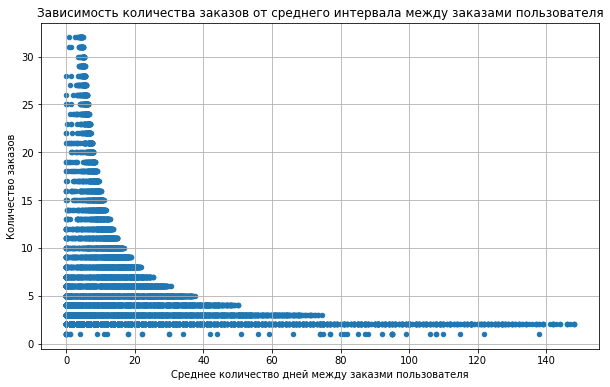

In [145]:
# График зависимости количества заказов от среднего интервала между заказами пользователя
df_profile.plot(
    kind="scatter",
    x="avg_days_between",
    y="count_orders",
    title="Зависимость количества заказов от среднего интервала между заказами пользователя",
    xlabel="Среднее количество дней между заказами пользователя",
    ylabel="Количество заказов",
    figsize=(10, 6),
    grid=True
)
plt.show()

На полученном графике видна явная зависимость между средним количеством дней между заказами пользователя и его количеством покупок - зная средний интервал между покупками пользователя можем предположить, что его количество покупок не превышает соответствующего данному интервалу значения из графика.

Найдём корреляции с другими столбцами при выделении различных сегментов количества заказов.

Рассмотрим корреляции количества заказов пользователя при сегментации по колическву заказов: **2-4 заказа**, **5 и более заказов**.
**Сегмент с 1 заказом рассматриваться не будет так как по нему невозомжно построить матрицу корреляции**, так как в столбце с количеством заказов присутствует только одной уникальное значение.

In [97]:
# Создание датафреймов соответствующих выделенным сегментам
df_profile_is_two_four = df_profile[df_profile["is_two"] & ~df_profile["is_five"]]
df_profile_is_five = df_profile[df_profile["is_five"]]

In [98]:
# Убираем столбец с id пользователя и производные столбцы от count_orders в каждом используемом датафрейме
df_profile_is_two_four_for_corr = df_profile_is_two_four.drop(["user_id", "is_two", "is_five"], axis=1)
df_profile_is_five_for_corr = df_profile_is_five.drop(["user_id", "is_two", "is_five"], axis=1)


**Сегмент с 2-4 заказами у пользователей**

interval columns not set, guessing: ['count_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between', 'day_of_week_first', 'lifetime']
Матрица корреляций для столбца count_orders:
                   count_orders
dt_first               0.220125
dt_last                0.165999
device_first           0.000000
region_first           0.000000
service_first          0.066518
genre_first            0.000000
avg_revenue            0.051564
avg_tickets            0.370830
avg_days_between       0.385359
day_of_week_first      0.000000
lifetime               0.284764


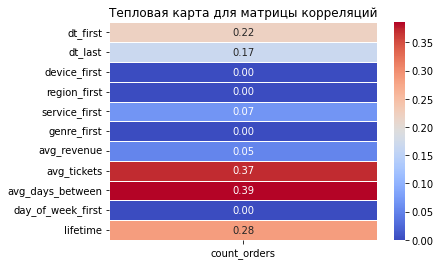

In [99]:
create_corr_matrix_one_col(df_profile_is_two_four_for_corr, "count_orders")

В данном сегменте количество заказов меньше зависит от лайфтайма (коэф. корреляции 0.28) и среднего количества дней между заказами (коэф. корреляции 0.39), чем при общей выборке. Однако становится сильнее зависимость от среднего количества билетов в заказе (**коэф. корреляции 0.37**). Рассмотрим найденную зависимость от среднего количества билетов.

Рассмотрим ожидаемые количества билетов для каждого количества заказов.

In [162]:
# Группируем пользователей по количеству заказов и вычисляем медианное значение количества билетов в каждой группе
df_profile_is_two_four_grouped = df_profile_is_two_four_for_corr.groupby("count_orders")[["avg_tickets"]].median()
df_profile_is_two_four_grouped

,avg_tickets
count_orders,
2,2.500000
3,2.666667
4,2.750000


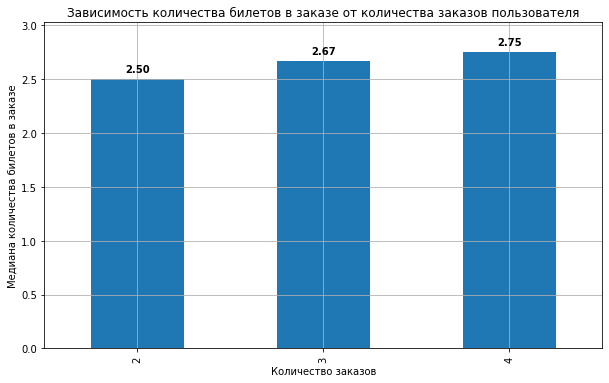

In [176]:
plot = df_profile_is_two_four_grouped.plot(
    kind="bar",
    title="Зависимость количества билетов в заказе от количества заказов пользователя",
    xlabel="Количество заказов",
    ylabel="Медиана количества билетов в заказе",
    figsize=(10, 6),
    grid=True,
    legend=()
)

plot.bar_label(
    plot.containers[0], 
    labels=[format(i[0], "0.2f") for i in df_profile_is_two_four_grouped.values],
    padding=5,
    fontweight='bold'
)

plot.set_ylim(0, df_profile_is_two_four_grouped.values.max() * 1.1)
    
plt.show()

Из полученного графика видно, что присутствует слабая зависимость между средним количеством билетов в заказе и количеством заказов у пользователя, так как при увелечении количества заказов также растёт и медиана количества билетов в заказе. Зависимость является слабой, так как при использовании вместо медианы среднего, зависимость не будет видна, потому что в среднем количестве билетов в заказах пользователей присутствуют выбросы.

**Сегмент с 5 и более заказами у пользователей**

interval columns not set, guessing: ['count_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between', 'day_of_week_first', 'lifetime']
Матрица корреляций для столбца count_orders:
                   count_orders
dt_first               0.162465
dt_last                0.000000
device_first           0.031634
region_first           0.000000
service_first          0.040628
genre_first            0.059168
avg_revenue            0.072086
avg_tickets            0.131259
avg_days_between       0.712341
day_of_week_first      0.000000
lifetime               0.473982


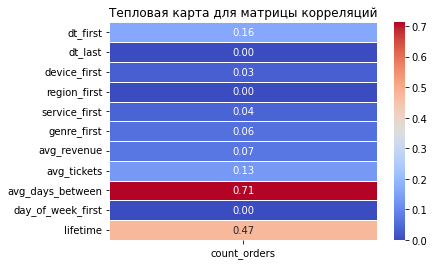

In [177]:
create_corr_matrix_one_col(df_profile_is_five_for_corr, "count_orders")

В данном сегменте остались видны только уже выявленные зависимости (с лайфтаймом пользователя и со средним интервалом между заказами). Можно отметить, что **зависимость от среднего количества дней между заказами пользователя стала более сильная**, рассмотрим эту зависимость на графике.

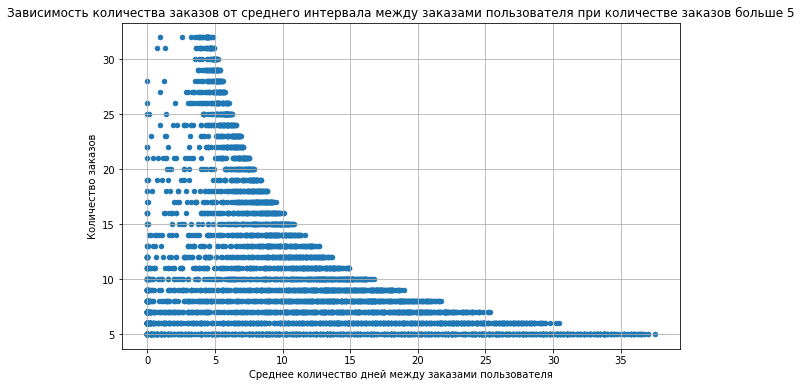

In [178]:
# График зависимости количества заказов от среднего интервала между заказами пользователя при количестве заказов больше 5
df_profile_is_five_for_corr.plot(
    kind="scatter",
    x="avg_days_between",
    y="count_orders",
    title="Зависимость количества заказов от среднего интервала между заказами пользователя при количестве заказов больше 5",
    xlabel="Среднее количество дней между заказами пользователя",
    ylabel="Количество заказов",
    figsize=(10, 6),
    grid=True
)
plt.show()

Из полученного графика видно, что зависимость стала более линейной в отличии от зависимости выявленной на общей выборке, это наблюдение и является причиной изменения коэффициента корреляции с данным столбцом.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Информация о данных**

В ходе выполенния запроса к базе данных был получен датасет, состоящий из 290611 строк и 15 столбцов и содержащий информацию о заказах в сервисе Яндекс Афиша. В данных пропуски были обнаружены только в столбце содержащем количества дней между заказами (они обусловлены смыслом самого столбца). В столбце, содержащем выручку с заказа, ыбли обнаружены отрицательные значения и было выдвинуто предположение, что такие значения означают возврат товара.

В течении предобработки данных была **преобразована выручка записанная в тенге и рублях в только рубли** с помощью обращения к курсу данных валют за соответствующую дату. Также была **сокращена размерность** многих числовых столбцов и столбцов, содержащих дату и время. Далее была проведена **фильтрация по значениям выручки с заказов**: были удалены заказы чья выручка превышает значение 99 перцентиля. В ходе преобработки **был удалён 1% от всех данных**.

**Основные результаты анализа**

- Сначала был создан профиль пользователя, содержащий основную важную инфомрацию о конкретных пользователях сервиса. Всего было составлено **21723 профиля уникальных пользователей** со **средней выручкой 549 рублей**. Во время изучения статистических показателей пользователей было выяснено, что большая часть пользователей возвращались к использованию сервиса после первой покупки, что означает **хорошее удержание пользователей**. Полученные профили пользователей также **были отфильтрованы**, так как в некоторых их них было больше 150 покупок за 5 месяцев, что является аномальным значением.
- Было найденно несколько признаков первого заказа, которые **положительно влияют на возвратность клиента** (после покупки билета на мероприятие с таким признаком пользователь возвращался с наибольшей вероятностью):
    - покупка билетов на концерты, театры или выставки;
    - покупка билетов на мероприятия, проходящие в Светополянском округе или в Широковской области.
    - обращение к билетному оператору "Край билетов" или "Дом культуры".
- Была обнаружена **зависимость между количеством заказов и средней выручкой пользователя**: чем меньше количество заказов, тем больше вероятность того, что средняя выручка будет находится в диапазоне **от 1000 рублей** и **до 250 рублей**.
- **Чаще всего делают повторные покупки пользователи, чьи первые заказы включали в себя покупку 2-3 билетов**. В таком случае вероятность повторной покупки составляла **71%**.
- Во время анализа временных характеристик не было обнаружено сильного влияния дня недели первой покупки на удержание пользователя, однако была доказана гипотеза о том, что, **чем меньше интервал времени между заказами, тем выше количество заказов у пользователя**.
- В результате проведения корреляционного анализа была найдена **сильная зависомость между лайфтаймом пользователя и ожидаемым количеством заказов** у него, а также была найдена **зависимость между средним интервалом между заказами пользвоателя и ожидаемым количеством его заказов**. При рассмотрении сегмента пользователей с более чем 5 заказами было обнаружено, что зависимость количества заказов от среднего интервала между заказами **увеличивается** и становится почти линейной.

В качестве итоговой рекомендации, предлагается следующее:
- обратить внимание на спортивные мероприятия, так как несмотря на их большую популярность, очень мало людей покупающих билеты на них возвращаются в сервис, возможно это связано с более выгодными условиями у конкурентов;
- рассмотреть сотрудничество с билетными операторами "Край билетов" и "Дом культуры", потмоу что большая доля пользователей покупающих у них билеты возвращалась на сервис, но количество таких пользователей мало; возможно стоит предлагать данных билетных операторов на главной странице сервиса;
- создать специальные предложения на покупку большого количества билетов (например, от 4 штук);
- организовать скидки на покупку билетов в воскресенье, так как в этот день наблюдается минимальное число покупок.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**